# E9 GNN Navigation

Author: Arush Arora

## Introduction

This codebase has mostly consisted of additive Graph Positional Encodings (GREPs) injections to provide nodal embeddings to the LLMs at hand. This new multi-stage training will rely on training an R-PEARL/GT to simply replicate the shortest-distance paths of the graph before expecting it to serve the LLM with **multiplicative** GREPs for navigation tasks, which will be factored directly into the attention-mask matrix for rendition to the LLM (as a Hadamard product cover on the attention logits). Thus, the system will be more carefully trained to incorporate the variation in model architecture among GNNs and LLMs (in terms of their pre-trained weights rather than simply their mathematical foundations).

## Mathematical Overview

### The R-PEARL GNN

The Random Positional Encoding (R-PEARL) GNN architecture is a PE generator that inputs white noise and processes it over an undirected graph $\mathcal{G} = (\mathcal{V}, \mathcal{E}, \mathcal{W})$. In this work, the graph is represented by an adjacency matrix $A$, and the GNN composes [Topology Adaptive Graph (TAG)](https://arxiv.org/abs/1710.10370) Convolutional Layers with pointwise nonlinearities (demodulators).

#### Graph Convolutional Network (GNN)

The code below establishes this project's implementation of a Graph Convolutional Network, which is the foundational architecture comprising R-PEARL. The equation to demonstrate the internal architecture of this NN as follows (in most cases, $\mathbf{P}(\cdot) = \mathbf{I}(\cdot)$, where $\mathbf{I}$ is the identity function):
$$\Phi(\mathbf{X}, \mathbf{S}, \mathcal{H}) = \mathbf{X}^{(L)}$$
$$\mathbf{X}^{(0)} = \mathbf{X} \qquad \mathbf{X}^{(l)} = \mathbf{P}\Bigg[\sigma\Bigg(\sum_{k = 0}^{K^{(l)} - 1} \mathbf{S}^k\mathbf{X}^{(l - 1)}\mathbf{H}_k^{(l)}\Bigg)\Bigg]$$

#### Random Graph Positional Encodings (R-PEARL)

The R-PEARL architecture extends on the GCN by instantiating it with simply one layer – a TAG Convolution and Demodulator. The mathematical equations below express the functionality of the R-PEARL network:
1. The white-noise matrix is sampled from the Gaussian distribution. $$\mathbf{Q} \in \mathbb{R}^{M \times N} \qquad \mathbf{Q} \sim \mathcal{N}(0, \mathbf{I}) \qquad \mathbf{Q} = \begin{bmatrix}
  \mathbf{q}^{(0)} & \cdots & \mathbf{q}^{(m)} & \cdots & \mathbf{q}^{(M)}
  \end{bmatrix}$$

2. The R-PEARL network has row-vector parameter $\mathbf{H}^{(0)} \in \mathbb{R}^{1 \times D}$. It takes in each column of the white-noise matrix individually and produces a sample $\mathbf{P}^{(m)} \in \mathbb{R}^{N \times D}$, which are then pooled to form GREP $\mathbf{P}$:$$\mathbf{P}^{(m)} = \Phi\Big(\mathbf{q}^{(m)};\, \mathbf{S}, \mathcal{H}\Big) = \sigma\bigg(\sum_{k = 0}^{K = 1} \mathbf{S}^k\mathbf{q}^{(m)} {\mathbf{H}}_k\bigg)$$ $$\mathbf{P} = \mathbb{\hat{E}}\Big[\mathbf{p}^{(m)}\Big] = \frac{1}{M}\sum_{m = 1}^{M} \mathbf{P}^{(m)}$$

### Sparse Graph Transformer

The Sparse Graph Transformer (hereafter named Graph Transformer or GT) follows the same architecture as that of a normal transformer, albeit that the attention mecahnism is modified to scope only over the $k$-hop neighborhood of the query node. The mathematical equations below express the functionality of the Graph Transformer:
$$\mathbf{X}_L = \Phi\Big(\mathbf{X}_0 + \mathbb{\hat{E}}_{\mathbf{q \sim \mathcal{N}(0,\, \mathbf{I})}}\big[\Phi(\mathbf{q};\, S, \mathcal{H})\big];\, \mathcal{T}\Big)$$
$$\mathbf{A}^{(h)}_l = \left[\frac{\exp\left[\left(\mathbf{Q}^{(h)}_l \mathbf{x}_{l-1,\ t}\right)^\top \left(\mathbf{K}^{(h)}_l \mathbf{X}_{l-1,\ U}\right)\right]}{\mathbf{1}^\top \exp\left[\left(\mathbf{Q}^{(h)}_l \mathbf{x}_{l-1,\ t}\right)^\top \left(\mathbf{K}^{(h)}_l \mathbf{X}_{l-1,\ U}\right)\right]}\right]^\top_{\begin{subarray}{l}t \in [N] \\[2.5pt] U = \mathcal{N}^{\le k}(t)\end{subarray}}$$
$$\mathbf{Y}^{(h)}_l = \left(\mathbf{W}_o\right)^\top_l \mathbf{V}_l \mathbf{X}_{l - 1} \left(\mathbf{A}^{(h)}_l\right)^\top$$
$$\mathbf{X}_l = \sigma\bigg(\sum_{h = 1}^H \mathbf{Y}^{(h)}_l\bigg)$$

### Transformer

The Transformer architecture follows that of the Llama3.1-8B distilled PRISM model. First, the TXT file, containing the scene-graph data, is tokenized and embedded into matrices $E$ and $\tilde{X}$ as follows, where $V$ is the size of the vocabulary and $d$ is the embedding dimension.

$$\text{TXT Tokenized Data from GPT-4: } E = \begin{bmatrix}
\mathbf{e}_1 & \mathbf{e}_2 & \overset{\mathbf{e}_t}{\cdots} & \mathbf{e}_T
\end{bmatrix}^\top \qquad \mathbf{e}_t \in \mathbb{R}^V$$

$$\text{Embed: } X = \begin{bmatrix}
\mathbf{x}_1 & \mathbf{x}_2 & \overset{\mathbf{x}_t}{\cdots} & \mathbf{x}_T
\end{bmatrix}^\top \qquad \mathbf{x}_t \in \mathbb{R}^d$$

Next, the transformer operates using the equations below:

$$\mathbf{X} = \mathbf{\tilde{X}} + \mathbf{P}$$

$$\mathbf{Z}_{1:t}^{(L)} = \operatorname{Trf}\Big(\mathbf{X}_{1:t}, {\mathcal{T}}_l\Big) \qquad {\mathcal{T}}_l = \begin{bmatrix}
\mathbf{Q}_l & \mathbf{K}_l & \mathbf{V}_l & \left(\mathbf{W}_o\right)_l
\end{bmatrix}^\top \in \mathbb{R}^{4 \times T \times D}$$

$$\hat{\mathbf{Y}}_{t + 1} = \operatorname{Linear}\Big(\mathbf{Z}_{1:t}^{(L)}\Big) \in \mathbb{R}^V$$
$$\text{Cross-Entropy Loss: } \mathcal{L}(E, \hat{\mathbf{Y}}) = \sum_t \sum_v e_{vt}\log{\hat{y}_t}$$

### Graph-Augmented LLM

The last class that is needed to create the full GREP-PRISM architecture is the `GraphAugmentedLLM`, which simply implements the following equation as a Neural Network object in PyTorch's `torch.nn` module (referring to above equations for definitions).
$$\mathbf{P} = \mathbb{\hat{E}}\Big[\mathbf{p}^{(m)}\Big] = \frac{1}{M}\sum_{m = 1}^{M} \Phi\Big(\mathbf{q}^{(m)}, \mathbf{S}, \mathcal{H}\Big)$$

$$\mathbf{X} = \mathbf{\tilde{X}} + \mathbf{P}$$

$${\mathbf{Z}}_{1:t}^{(L)} = \operatorname{Trf}\Big({\mathbf{X}}_{1:t}; \, \cdot \,\Big)$$

## Setup

In [1]:
# %env CUDA_VISIBLE_DEVICES=0
%load_ext autoreload
%autoreload 2

In [2]:
# Import modules.
import gc
import copy
import wandb
import torch
import random
import pickle
import sympy as sp
import numpy as np
import networkx as nx

from typing import Union

from torch import nn
import matplotlib.pyplot as plt
from IPython.display import display
from torch_geometric.data import Data
from torch.nn.utils import clip_grad_norm_
from torch_geometric.utils import to_networkx
from torch_geometric.loader import DataLoader
from torch.distributions import Cauchy, Normal
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.utils import to_dense_adj, to_networkx

from prism.models.gt import GraphTransformer, SemanticGraphTransformer
from prism.models.r_pearl import RandomGNNPositionalEncodings
from prism.data import data, utils

In [3]:
# Weights & Biases setup. Mirrors prism.training.train_v3._setup_wandb (project /
# name / tags / group + full-config logging), adapted for this notebook's hand-written
# train loops. Each training stage gets its own run, grouped/tagged by GNN type so the
# R-PEARL and GT variants of the same stage line up on one W&B dashboard. The helpers
# introspect the live optimizer / scheduler / loss objects so EVERY hyperparameter is
# logged without hand-maintaining a list.
WANDB_PROJECT = 'e9-gnn-navigation'


def optimizer_hparams(optimizer):
    """Every optimizer setting: class name, shared defaults, and per-param-group values
    (LRs, betas, eps, weight_decay, ...) with the parameter tensors stripped out."""
    return {
        'optimizer': type(optimizer).__name__,
        'optimizer_defaults': dict(optimizer.defaults),
        'param_groups': [
            {k: v for k, v in g.items() if k != 'params'}
            for g in optimizer.param_groups
        ],
    }


def scheduler_hparams(scheduler):
    """Every LR-scheduler setting (or {'scheduler': None} when unused)."""
    if scheduler is None:
        return {'scheduler': None}
    keys = ('mode', 'factor', 'patience', 'threshold', 'threshold_mode',
            'cooldown', 'min_lrs', 'eps')
    return {
        'scheduler': type(scheduler).__name__,
        **{k: getattr(scheduler, k) for k in keys if hasattr(scheduler, k)},
    }


def loss_hparams(loss_fn):
    """Loss class, reduction, and pos_weight (resolved to plain Python)."""
    out = {'loss_fn': type(loss_fn).__name__,
           'reduction': getattr(loss_fn, 'reduction', None)}
    pos_weight = getattr(loss_fn, 'pos_weight', None)
    if pos_weight is not None:
        out['pos_weight'] = (pos_weight.detach().cpu().tolist()
                             if torch.is_tensor(pos_weight) else pos_weight)
    return out


def init_wandb(stage, hparams):
    """Start a W&B run for a training `stage` ('edge_detection' / 'path_navigation').

    Logs the FULL run config: the GNN construction kwargs (`model_hparams`, set in the
    GNN-instantiation cell) plus every optimizer / scheduler / loss / batching
    hyperparameter the caller assembles in `hparams`. `model_type` selects R-PEARL vs
    GT and drives the run name / tag / group. Returns the run; `reinit=True` so
    successive stages in one notebook session each open a fresh run.
    """
    return wandb.init(
        project=WANDB_PROJECT,
        name=f'{stage}_{model_type}',
        tags=[stage, model_type],
        group=model_type,
        config={'model_type': model_type, 'stage': stage,
                'model': model_hparams, **hparams},
        reinit='return_previous',
    )

In [4]:
# Define a tensor rendering function.
def render_matrix(mat: torch.tensor, sig_figs: int = 3, decimals: int = 0):
    out = sp.Matrix(mat.detach().cpu().numpy())
    if sig_figs > 0:
        return sp.N(out, sig_figs)
    if decimals > 0:
        return out.applyfunc(lambda x: x.round(decimals))
    return out

In [5]:
# Standard options.
gnn_path  = '/home/shared/GREP-PRISM/outputs/e13f_alpha_khops/e13f_alpha00_ai8c2bm0/gnn_weights.pt'
ex_path   = '../data/n_30/gen/nav100_n30_gemma_data/split/test_graphs'
eval_path = '../data/n_100/gen/nav_n100_gemma_data/test_graphs' # 'data_store/old/eval/e6_transferability'
save_path = '../data/pickle/e6_eval_graphs.pkl'
device    = 'cuda'

In [6]:
# Setup eval infrastructure.
samples_by_graph, graph_file_by_name = data.load_samples_by_graph(ex_path)
graph_file = random.choice(list(samples_by_graph.keys()))
eval_data = samples_by_graph[graph_file]
eval_data = {graph_file: [random.choice(eval_data)]}

In [7]:
print(f'/Users/cyberlives/Documents/GitHub/GREP-PRISM/eval/render/revised/{graph_file}.html')

/Users/cyberlives/Documents/GitHub/GREP-PRISM/eval/render/revised/data_gen_009.html


## Experiments

### §1 Pretraining a GNN to Classify Edge Existence

We first hope to optimize a GNN (R-PEARL or Graph Transformer) to classify whether an edge exists in the graph or not. Such a model will serve as a backbone pretrained model for fine-tuning on reporting shortest paths. The equations to represent this procedure are below:
$$\mathbf{H} = \mathbf{\Psi} = \Phi\Big(\mathbb{\hat{E}}_{\mathbf{q}}\big[\Phi(\mathbf{q};\, S, \mathcal{H})\big];\, \mathcal{T}\Big)$$
$$\mathbf{\hat{y}}_{ij} = \text{MLP}\big[\mathbf{h}_i\ \Vert\ \mathbf{h}_j\ \Vert\ \mathbf{h}_i \odot \mathbf{h}_j\ \Vert\ |\mathbf{h}_i - \mathbf{h}_j\|\big] \in [0, 1]$$

#### Model Definitions

We first define the models.

In [8]:
# Instantiate a GNN. `model_type` / `model_hparams` are exposed at module scope so
# init_wandb can log the GNN config; create_gnn writes model_hparams as it builds.
def create_gnn(model_type: str):
    global model_hparams
    if model_type == 'gt':
        model_hparams = dict(
            num_layers=3,
            pe_hidden_channels=256,
            pe_num_layers=5,
            d_model=1024,
            heads=8,
            num_samples=320,
            dropout=0.1,
            k_pe=3,
            k_gt=2,
            eps=1e-6,
            use_layer_norm=True,
        )
        gnn = GraphTransformer(**model_hparams)
        gnn.out_features = gnn.d_model
    else:
        model_hparams = dict(
            pe_hidden_channels=256,
            pe_num_layers=5,
            d_model=1024,
            num_samples=320,
            dropout=0.1,
            k=3,
            eps=1e-6,
            use_layer_norm=True,
        )
        gnn = RandomGNNPositionalEncodings(**model_hparams)
        gnn.out_features = gnn.output_projection.out_features
    return gnn


model_type = 'gt'
gnn = create_gnn(model_type)

In [9]:
# Define a class for edge detection and instantiate it.
class GNNEdgeDetector(nn.Module):
    """
    Simple class to detect whether Node 1 and Node 2 are connected by
    applying an MLP to the Graph Positional Encodings of both nodes concatenated.
    """
    def __init__(self, gnn: Union[RandomGNNPositionalEncodings, GraphTransformer]):
        super(GNNEdgeDetector, self).__init__()
        self.gnn = gnn
        shape = self.gnn.out_features
        self.classifier = nn.Sequential(
            nn.Linear(4 * shape, shape),
            nn.LeakyReLU(),
            nn.Linear(shape, 1),
        )
        self.graph = Data(
            x=torch.empty((0, 0), dtype=torch.float),
            edge_index=torch.empty((2, 0), dtype=torch.long)
        )
        self.cached_pe = torch.zeros(size=(1, shape))

    def forward(self, graph: Data, node1: int, node2: int):
        if self.cached_pe is None or not self.cached_pe.any() or self.graph is not graph:
            self.graph = graph
            self.cached_pe = self.gnn(self.graph)
        hi, hj = self.cached_pe[node1], self.cached_pe[node2]
        return self.classifier(torch.cat((hi, hj, hi * hj, abs(hi - hj)), dim=0))
    
    def invalidate_cache(self):
        self.graph = None
        self.cached_pe = None


# Instantiate the class.
detector = GNNEdgeDetector(gnn)

#### Numeric Visualizations with SymPy

Using the `render_matrix()` function defined at the very beginning of this notebook, we explore the procedure needed to preprocess a pre-training set for the GNN to reconstruct the graph adjacency given a scene graph PyTorch `Data` object.

In [10]:
# Sampling options and operators.
_p = lambda v: torch.tensor(v, device='cuda', dtype=torch.float)
BASE_LOC, BASE_SCALE, CAUCHY_SCALE = _p(0.0), _p(0.1), _p(1.0)

In [11]:
# Prepare a graph from the data to be used in the GNN.
load_ex_graph = False

if load_ex_graph:
    with open(save_path, 'rb') as file:
        ex_graph = pickle.load(file)[4]
        N = ex_graph.num_nodes
else:
    ex_graph = utils.scene_graph_dict_to_pyg(eval_data[graph_file][0][2], 'binary')

    N, D = ex_graph.num_nodes, gnn.out_features
    ex_graph.edge_index = ex_graph.edge_index.to(device)
    ex_graph.x = Cauchy(loc=BASE_LOC, scale=BASE_SCALE).sample((N, D)).to(device)

    EPS = 1e-12
    MAX_LENGTH = 128
    g = to_networkx(ex_graph, to_undirected=True)
    ex_graph.nxg = g
    all_pairs = dict(nx.all_pairs_dijkstra(g, weight=None))
    delta_max = max(len(path) for target in all_pairs.values() for path in target[1].values())
    paths = torch.full((N, N, delta_max if delta_max < MAX_LENGTH else MAX_LENGTH), -1).long()
    dist = torch.full((N, N), float('inf'))
    for u, (lengths_u, paths_u) in all_pairs.items():
        for v, p in paths_u.items():
            dist[u, v] = lengths_u[v]
            p = (
                torch.tensor(p, device=device).long() if len(p) < MAX_LENGTH 
                else torch.full((MAX_LENGTH,), -1, device=device).long()
            )
            paths[u, v, 0:len(p)] = p
            paths[v, u, 0:len(p)] = p.flip(0)
    dist.fill_diagonal_(EPS)
    ex_graph.diameter = delta_max
    ex_graph.paths = paths.to(device)
    ex_graph.dist = dist.to(device)

    # Topology only: BFS hop counts, never weighted, so metric distances in `dist`
    # can never reach the blurry-vision mask.
    hops = torch.full((N, N), float('inf'))
    for u, lengths_u in nx.all_pairs_shortest_path_length(g):
        for v, h in lengths_u.items():
            hops[u, v] = h
    assert torch.equal(hops[hops.isfinite()], hops[hops.isfinite()].round()), \
        'graph.hops must stay integral (unweighted BFS)'
    ex_graph.hops = hops.to(device)

    # Dense adjacency (bool).
    ex_graph.adj = to_dense_adj(
        ex_graph.edge_index, max_num_nodes=N
    ).squeeze(0).bool().to(device)

# Show the shortest paths matrix of a node in the graph.
node1 = random.randint(0, N - 1)
node2 = random.randint(0, N - 1)
render_matrix(ex_graph.paths[node1, node2][None, :], sig_figs=0)

Matrix([[23, 26, 20, 21, 3, -1, -1]])

In [12]:
# Feed the matrix to the GNN.
gnn.eval()
with torch.no_grad():
    out = gnn(ex_graph).to(device)

_, _, V = torch.pca_lowrank(out.cpu(), q=10, center=True)
out = out - out.mean(dim=0)
render_matrix(out @ V.to(device))

Matrix([
[ -6.94,  -0.112,   0.458,   -0.49,   0.402,   -0.363,    -0.355,   0.0238,   -0.132,    0.085],
[ -6.07,   0.939,  -0.281,   0.128,  -0.298,    0.326,     -0.36,    0.146,   0.0488,   0.0274],
[  -7.1, -0.0948, -0.0807,    0.52,   0.167,    0.322, -0.000766,   -0.232,   0.0264,    0.128],
[ -7.51,   0.745,  -0.664,   0.774,  0.0399,   0.0263,     0.188,    0.255,  -0.0295,   -0.116],
[ -6.65,   0.322,  -0.279,   -0.45,   0.086,   0.0077,    0.0802,   0.0818,   -0.113,  -0.0186],
[ -7.37,  -0.523,   0.211,  -0.365,   0.575,   -0.209,     0.272,   -0.258,    0.112,  -0.0849],
[  3.06,     1.3,  -0.214,  -0.111,    0.12,   0.0416,    0.0683,   0.0107,    0.247,   0.0947],
[  1.78,   -1.29,  -0.321,  0.0721,   -0.11,     0.19,    -0.194,   -0.159,   0.0448, -0.00325],
[  1.63,    1.52,  -0.534, -0.0467,  -0.392,   -0.226,    -0.222,   -0.191,  -0.0154,  -0.0386],
[  3.02,    1.41, -0.0455,   0.228,   0.113,    0.014,    -0.143,   -0.144,   0.0835,  -0.0511],
[   3.3, -0.0435,   -

In [13]:
# Test out the Detector.
detector.eval()
node1, node2 = random.sample(range(ex_graph.num_nodes), k=2)
with torch.no_grad():
    out = detector(ex_graph, node1, node2).to(device)

print(node1, node2)
render_matrix(out.sigmoid())

5 4


Matrix([[0.517]])

#### Pre-Training of GNN on Edge Incidence

Next, we actually preprocess and train the GNN using the steps defined above.

In [14]:
# Init variables.
load_test_graphs = False
use_1000_nodes = False

# Configure the training and test datasets.
train_dataset, _ = data.load_samples_by_graph(
    '../data/n_30/gen/nav100_n30_gemma_data/split/train_graphs'
)
test_dataset, _ = data.load_samples_by_graph(
    eval_path
)

# Configure the validation dataset.
EPS = 1e-12
MAX_LENGTH = 128
train_prop = 0.8
train_num = len(train_dataset)
train_keys = random.sample(list(train_dataset.keys()), k=int(train_num * train_prop))
val_dataset = {k: v for k, v in train_dataset.items() if k not in train_keys}
train_dataset = {k: v for k, v in train_dataset.items() if k in train_keys}

# Preprocess the data.
def generate_data(dataset):
    graphs = [utils.scene_graph_dict_to_pyg(v[0][2], 'binary') for _, v in dataset.items()]
    for graph in graphs:
        N = graph.num_nodes
        graph.edge_index = graph.edge_index.to(device)
        graph.x = Cauchy(loc=BASE_LOC, scale=CAUCHY_SCALE).sample((N, 1)).to(device)

        # Distances and paths.
        g = to_networkx(graph, to_undirected=True)
        graph.nxg = g
        all_pairs = dict(nx.all_pairs_dijkstra(g, weight=None))
        delta_max = max(len(path) for target in all_pairs.values() for path in target[1].values())
        paths = torch.full((N, N, delta_max if delta_max < MAX_LENGTH else MAX_LENGTH), -1).long()
        dist = torch.full((N, N), float('inf'))
        for u, (lengths_u, paths_u) in all_pairs.items():
            for v, p in paths_u.items():
                dist[u, v] = lengths_u[v]
                p = (
                    torch.tensor(p, device=device) if len(p) < MAX_LENGTH 
                    else torch.full((MAX_LENGTH,), -1, device=device)
                )
                paths[u, v, 0:len(p)] = p
                paths[v, u, 0:len(p)] = p.flip(0)
        dist.fill_diagonal_(EPS)
        graph.diameter = delta_max
        graph.paths = paths.to(device)
        graph.dist = dist.to(device)

        # Topology only: BFS hop counts, never weighted, so metric distances in `dist`
        # can never reach the blurry-vision mask.
        hops = torch.full((N, N), float('inf'))
        for u, lengths_u in nx.all_pairs_shortest_path_length(g):
            for v, h in lengths_u.items():
                hops[u, v] = h
        assert torch.equal(hops[hops.isfinite()], hops[hops.isfinite()].round()), \
            'graph.hops must stay integral (unweighted BFS)'
        graph.hops = hops.to(device)

        # Dense adjacency (bool).
        graph.adj = to_dense_adj(
            graph.edge_index, max_num_nodes=N
        ).squeeze(0).bool().to(device)

        # Edges.
        combs = torch.triu_indices(N, N, offset=1, device=device)
        edge_codes = graph.edge_index[0] * N + graph.edge_index[1]
        existence = torch.isin(combs[0] * N + combs[1], edge_codes)
        graph.exclusion = combs[:, ~existence].to(device)
        indices = torch.randint(
            high=graph.exclusion.shape[1], size=(graph.edge_index.shape[1],), device=device
        )
        graph.edges_x = torch.cat((graph.edge_index, graph.exclusion[:, indices]), dim=1).to(device)
        graph.edges_y = torch.cat(
            (torch.ones((graph.edge_index.shape[1],)), torch.zeros((indices.shape[0],))), dim=0
        ).to(device)

    return graphs


def reshuffle(graphs):
    """Function for reshuffling edge data during training."""
    for graph in graphs:
        indices = torch.randint(
            high=graph.exclusion.shape[1], size=(graph.edge_index.shape[1],), device=device
        )
        graph.edges_x = torch.cat((graph.edge_index, graph.exclusion[:, indices]), dim=1).to(device)
        graph.edges_y = torch.cat(
            (torch.ones((graph.edge_index.shape[1],)), torch.zeros((indices.shape[0],))), dim=0
        ).to(device)

    return graphs


train_graphs = generate_data(train_dataset)
val_graphs = generate_data(val_dataset)

if not use_1000_nodes:
    test_dataset = {k: v for k, v in test_dataset.items() if k not in ['eval_graph_unique_1000']}

if load_test_graphs:
    with open(save_path, 'rb') as file:
        test_graphs = pickle.load(file)
else:
    test_graphs = generate_data(test_dataset)
    if use_1000_nodes:
        with open(save_path, 'wb') as file:
            pickle.dump(test_graphs, file)

In [15]:
# Train the GNNEdgeDetector to reconstruct the graph adjacency.
batch_size = 4
val_freq = 5
epochs = 150
es_patience = 5
train_edges = True

def test_loop_edges(dataloader, model, loss_fn, wandb_prefix=None, epoch=None):
    model.to(device)
    model.eval()
    size = len(dataloader.dataset)
    order = torch.randperm(size)
    test_loss, correct = 0, 0
    tp = fp = fn = tn = 0

    with torch.no_grad():
        for idx in order.tolist():
            graph = dataloader.dataset[idx]
            preds = torch.stack([
                model(graph, graph.edges_x[0, k], graph.edges_x[1, k])
                for k in range(graph.edges_x.shape[1])
            ]).squeeze(-1).to(device)
            test_loss += loss_fn(preds, graph.edges_y).item()
            true = graph.edges_y.bool()
            pred = preds > 0
            tp += (pred & true).sum().item()
            fp += (pred & ~true).sum().item()
            fn += (~pred & true).sum().item()
            tn += (~pred & ~true).sum().item()
            correct += ((preds.sigmoid() > 0.5).float() == graph.edges_y).float().mean().item()

    test_loss /= size
    correct /= size
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    bal_acc = 0.5 * (recall + tn / (tn + fp + 1e-9))
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, F1: {f1:.3f} | P: {precision:.3f} "
          f"| R: {recall:.3f} | Bal Acc: {(100*bal_acc):.1f}% | Avg loss: {test_loss:>8f} \n")
    # Log eval metrics under the given split prefix (e.g. 'val') when a run is active.
    if wandb_prefix is not None and wandb.run is not None:
        log = {
            f'{wandb_prefix}/loss': test_loss,
            f'{wandb_prefix}/accuracy': correct,
            f'{wandb_prefix}/f1': f1,
            f'{wandb_prefix}/precision': precision,
            f'{wandb_prefix}/recall': recall,
            f'{wandb_prefix}/bal_acc': bal_acc,
        }
        if epoch is not None:
            log['epoch'] = epoch
        wandb.log(log)
        # Final test metrics: also surface as run-summary headline numbers.
        if wandb_prefix == 'test':
            wandb.run.summary.update({k: v for k, v in log.items() if k != 'epoch'})
    return test_loss, f1


def train_loop_edges(train_dataloader, val_dataloader, test_dataloader, model,
               loss_fn, optimizer, scheduler, batch_size=20, epochs=50):
    size = len(train_dataloader.dataset)
    model.to(device)
    model.train()
    val_loss: float = 0
    best_val, best_state, bad_runs = float('inf'), None, 0
    # Log the full run config: GNN (model_hparams) + optimizer/scheduler/loss/batching.
    run = init_wandb('edge_detection', {
        'batch_size': batch_size, 'epochs': epochs,
        'val_freq': val_freq, 'es_patience': es_patience,
        **optimizer_hparams(optimizer),
        **scheduler_hparams(scheduler),
        **loss_hparams(loss_fn),
    })
    global_step = 0
    for i in range(epochs):
        # Validation loop.
        reshuffle(val_dataloader.dataset)
        if i % val_freq == 0:
            print(f"=============\nValidation #{i // val_freq + 1}\n=============")
            val_loss, _ = test_loop_edges(val_dataloader, model, loss_fn, wandb_prefix='val', epoch=i)
            if scheduler:
                scheduler.step(val_loss)
            if val_loss < best_val - 1e-3:
                best_val, bad_runs = val_loss, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                bad_runs += 1
                if bad_runs >= es_patience:
                    print(f"Early stop at epoch {i} (best val {best_val:>8f})")
                    break
            model.train()
        
        print(f"=============\nEpoch #{i + 1}\n=============")
        optimizer.zero_grad()
        pending = 0
        order = torch.randperm(size)
        reshuffle(train_dataloader.dataset)
        for j, idx in enumerate(order.tolist()):
            # Compute prediction and loss.
            graph = train_dataloader.dataset[idx]
            preds = torch.stack([
                model(graph, graph.edges_x[0, k], graph.edges_x[1, k])
                for k in range(graph.edges_x.shape[1])
            ]).squeeze(-1).to(device)
            loss = loss_fn(preds, graph.edges_y)

            # Backpropagation.
            (loss / batch_size).backward()
            pending += 1
            model.invalidate_cache()

            # Optimization and results.
            if pending == batch_size:
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
                pending = 0

                global_step += 1
                loss, current = loss.item(), j
                wandb.log({
                    'train/loss': loss,
                    'train/lr': optimizer.param_groups[0]['lr'],
                    'epoch': i,
                    'global_step': global_step,
                })
                print(f"Loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
        
        if pending:
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            pending = 0

    # Early stopping hatch.
    if best_state is not None:
        model.load_state_dict(best_state)
    
    # Test the finished model.
    test_loop_edges(test_dataloader, model, loss_fn, wandb_prefix='test')
    run.finish()


loss_fn = nn.BCEWithLogitsLoss()
train_dataloader = DataLoader(train_graphs, batch_size=batch_size)
val_dataloader = DataLoader(val_graphs, batch_size=batch_size)
test_dataloader = DataLoader(test_graphs, batch_size=batch_size)
if train_edges:
    optimizer = torch.optim.AdamW([
        {'params': detector.gnn.parameters(), 'lr': 3e-5},
        {'params': detector.classifier.parameters(), 'lr': 3e-4},
    ], betas=(0.9, 0.95), weight_decay=0.05)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    train_loop_edges(train_dataloader, val_dataloader, test_dataloader, detector,
                     loss_fn, optimizer, scheduler, batch_size=batch_size, epochs=epochs)
    del optimizer, scheduler
    gc.collect()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/arushar/.netrc.
wandb: Currently logged in as: arushar (alelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Validation #1
Test Error: 
 Accuracy: 30.8%, F1: 0.173 | P: 0.214 | R: 0.145 | Bal Acc: 30.6% | Avg loss: 0.701428 

Epoch #1
Loss: 0.701243  [    3/   32]
Loss: 0.646185  [    7/   32]
Loss: 2.382632  [   11/   32]
Loss: 2.151340  [   15/   32]
Loss: 0.848209  [   19/   32]
Loss: 0.947875  [   23/   32]
Loss: 1.391659  [   27/   32]
Loss: 1.160305  [   31/   32]
Epoch #2
Loss: 0.649861  [    3/   32]
Loss: 0.724970  [    7/   32]
Loss: 0.993369  [   11/   32]
Loss: 0.906206  [   15/   32]
Loss: 0.645895  [   19/   32]
Loss: 0.619108  [   23/   32]
Loss: 0.664280  [   27/   32]
Loss: 0.732898  [   31/   32]
Epoch #3
Loss: 0.535727  [    3/   32]
Loss: 0.665655  [    7/   32]
Loss: 0.730982  [   11/   32]
Loss: 0.702111  [   15/   32]
Loss: 0.618310  [   19/   32]
Loss: 0.517376  [   23/   32]
Loss: 0.627148  [   27/   32]
Loss: 0.631700  [   31/   32]
Epoch #4
Loss: 0.487613  [    3/   32]
Loss: 0.579246  [    7/   32]
Loss: 0.601926  [   11/   32]
Loss: 0.603746  [   15/   32]
Loss: 0

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇███
test/accuracy,▁
test/bal_acc,▁
test/f1,▁
test/loss,▁
test/precision,▁
test/recall,▁
train/loss,███▇▇▆▆▅▆▅▃▃▅▅▃▃▃▃▃▃▄▃▄▃▂▃▄▃▃▂▄▃▃▂▂▂▁▂▁▂
train/lr,█████████████████████████████▃▃▃▃▃▃▃▃▃▃▁
+6,...


In [16]:
if train_edges:
    torch.save(detector.state_dict(), '../outputs/e9_multistage_training/suite8/edge_detector.pt')
    torch.save(detector.gnn.state_dict(), f'../outputs/e9_multistage_training/suite8/edge_detector_{model_type}.pt')
else:
    detector.load_state_dict(torch.load('../outputs/e9_multistage_training/suite8/edge_detector.pt'))
    gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/edge_detector_{model_type}.pt'))

#### Evaluation of Pre-Trained GNN on Edge Incidence

We now test the trained model on the evaluation dataset. First, we we will render the output for clarity.

In [17]:
# Test out the Detector.
detector.eval().to(device)
detector.invalidate_cache()
node1, node2 = random.sample(range(ex_graph.num_nodes), k=2)
with torch.no_grad():
    out = detector(ex_graph, node1, node2)

print(node1, node2)
render_matrix(out.sigmoid())

14 24


Matrix([[4.98e-5]])

In [18]:
# Evaluate the GNN on its reconstruction of test graph adjacencies.
test_loop_edges(test_dataloader, detector, loss_fn)
pass

Test Error: 
 Accuracy: 81.9%, F1: 0.844 | P: 0.734 | R: 0.992 | Bal Acc: 81.7% | Avg loss: 0.734535 



### §2 Fine-tuning the GNN to Estimate Shortest-Path Distances

We now wish to optimize the pre-trained GNN (R-PEARL or Graph Transformer) to estimate the distance of the shortest path between two given nodes in the graph. Such a model will assist the shortest-path prediction model, serving as the backbone for the multi-stage training loop featured in E9 Multistage Training of the GREP-PRISM project. The equations to represent this procedure are below:
$$\mathbf{H} = \mathbf{\Psi} = \Phi\bigg(\Phi\Big(\mathbb{\hat{E}}_{\mathbf{q}}\big[\Phi(\mathbf{q};\, S, \mathcal{H})\big];\, \mathcal{T}\Big);\, S, \mathcal{H}\bigg)$$
$$c_2(\Psi, \Psi) = \sqrt{2\operatorname{diag}(\Psi^2) - 2\Psi^2} \approx [SPD]$$
$$\mathbf{E} = \mathbb{E}\left[\frac{[SPD]_{ij}}{\delta(i, j)}\right]_{i, j \in [N]}$$

#### Model Definitions

We first define the model by attaching a simple GCN head to the GNN positional encoder.

In [19]:
# Define a class for shortest-path distance estimation and instantiate it.
class GNNShortestPathsEstimator(nn.Module):
    """
    Simple class to predict the shortest-path distance graphical lasso estimator (covariance).
    """
    def __init__(self, gnn: Union[RandomGNNPositionalEncodings, GraphTransformer]):
        super(GNNShortestPathsEstimator, self).__init__()
        self.gnn = gnn
        shape = self.gnn.out_features
        self.head = nn.Sequential(
            nn.Linear(shape, shape),
            nn.LeakyReLU(),
            nn.Linear(shape, 1)
        )
        self.gate = nn.Parameter(torch.tensor(0.1))

    def forward(self, graph: Data):
        out = self.gnn(graph)
        out = self.head(out)
        out = torch.cdist(out, out, p=2)
        return self.gate * out

#### Numeric Visualizations with SymPy

Using the `render_matrix()` function defined at the very beginning of this notebook, we first explore the procedure needed to preprocess a pre-training set for the GNN to reconstruct the shortest-path distances matrix given a scene graph PyTorch `Data` object.

In [20]:
# Test out the SPD GNN.
spd_gnn = GNNShortestPathsEstimator(detector.gnn).to(device).eval()
with torch.no_grad():
    out = spd_gnn(ex_graph).to(device)

render_matrix(out)

Matrix([
[       0,   0.0174,  0.00705,  0.00759,  0.00687,  0.0226, 0.000195,  0.0378,  0.00358,  0.0101, 0.00376,   0.0172,  0.0297,  0.00812,  0.0122,   0.0328,    0.026,   0.0323,   0.0258,  0.0227,  0.0148,  0.0292,  1.64e-5, 0.00495,  0.0259, 0.00793,  0.0133,   0.0185,  0.00452,   0.0184],
[  0.0174,        0,   0.0245,    0.025,   0.0243,    0.04,   0.0176,  0.0552,    0.021,  0.0275,  0.0136, 0.000243,  0.0123,   0.0255,  0.0296,   0.0502,   0.0434,   0.0497,   0.0432,  0.0401,  0.0322,  0.0466,   0.0174,  0.0125,  0.0085, 0.00947, 0.00411,  0.00112,   0.0219, 0.000979],
[ 0.00705,   0.0245,        0,  0.00054, 0.000181,  0.0156,  0.00685,  0.0308,  0.00347, 0.00306,  0.0108,   0.0242,  0.0367,  0.00107, 0.00515,   0.0258,   0.0189,   0.0252,   0.0188,  0.0156, 0.00772,  0.0221,  0.00706,   0.012,   0.033,   0.015,  0.0203,   0.0256,  0.00253,   0.0254],
[ 0.00759,    0.025,  0.00054,        0, 0.000721,   0.015,  0.00739,  0.0302,  0.00401, 0.00252,  0.0113,   0.0247,  0.0373

In [21]:
# Render shortest-paths matrix.
render_matrix(ex_graph.dist)

Matrix([
[1.0e-12,     3.0,     4.0,     5.0,     5.0,     4.0,     1.0,     3.0,     2.0,     3.0,     2.0,     2.0,     3.0,     2.0,     3.0,     4.0,     4.0,     4.0,     5.0,     4.0,     4.0,     4.0,     4.0,     3.0,     4.0,     3.0,     3.0,     4.0,     3.0,     2.0],
[    3.0, 1.0e-12,     3.0,     5.0,     6.0,     5.0,     2.0,     2.0,     1.0,     2.0,     3.0,     3.0,     4.0,     3.0,     4.0,     4.0,     4.0,     3.0,     4.0,     4.0,     3.0,     4.0,     5.0,     4.0,     5.0,     4.0,     4.0,     5.0,     4.0,     3.0],
[    4.0,     3.0, 1.0e-12,     5.0,     5.0,     4.0,     3.0,     2.0,     2.0,     1.0,     2.0,     2.0,     3.0,     3.0,     3.0,     3.0,     4.0,     2.0,     3.0,     3.0,     3.0,     4.0,     4.0,     5.0,     4.0,     3.0,     4.0,     5.0,     4.0,     4.0],
[    5.0,     5.0,     5.0, 1.0e-12,     5.0,     5.0,     4.0,     3.0,     4.0,     4.0,     3.0,     4.0,     4.0,     3.0,     2.0,     3.0,     2.0,     3.0,     2.0,    

In [22]:
# Render error matrix.
render_matrix(out / ex_graph.dist)

Matrix([
[       0,   0.0058,  0.00176,  0.00152,  0.00137,  0.00565, 0.000195,  0.0126,  0.00179,  0.00337,  0.00188,  0.00858,   0.0099,  0.00406, 0.00407,   0.0082,   0.0065,  0.00807, 0.00517, 0.00567, 0.00369, 0.00729,  4.11e-6,  0.00165,  0.00648, 0.00264, 0.00443,  0.00463,  0.00151,  0.00919],
[  0.0058,        0,  0.00815,    0.005,  0.00404,    0.008,   0.0088,  0.0276,    0.021,   0.0138,  0.00455,   8.1e-5,  0.00307,  0.00851,  0.0074,   0.0126,   0.0108,   0.0166,  0.0108,    0.01,  0.0107,  0.0116,  0.00348,  0.00311,   0.0017, 0.00237, 0.00103, 0.000224,  0.00548, 0.000326],
[ 0.00176,  0.00815,        0, 0.000108,  3.62e-5,  0.00389,  0.00228,  0.0154,  0.00173,  0.00306,   0.0054,   0.0121,   0.0122, 0.000358, 0.00172,  0.00859,  0.00474,   0.0126, 0.00626, 0.00521, 0.00257, 0.00553,  0.00177,   0.0024,  0.00824, 0.00499, 0.00508,  0.00511, 0.000633,  0.00636],
[ 0.00152,    0.005, 0.000108,        0, 0.000144,    0.003,  0.00185,  0.0101,    0.001,  0.00063,  0.00378,

#### Definition of a Custom Loss Function: Graphical Lasso Estimator 

We seek to reproduce the [Graphical Lasso Estimator](https://en.wikipedia.org/wiki/Graphical_lasso) custom loss function within the PyTorch framework. Since such an error and gradient computation function requires a differentiable interpretation of the $L_1$ regularization penalty, we must define a new subclass of `torch.autograd.Function` to implement this regression objective within the working environment.

The Graphical Lasso Estimator is defined through the following mathematical optimizer:

$$\hat{\Theta} = \argmax_{\Theta \succ 0} L(\Theta) = \argmax_{\Theta \succ 0}\left(\log\det(\Theta) - \operatorname{tr}(S\Theta) - \lambda\sum_{i, j}|\Theta_{ij}|\right)$$

Thus, it has the following derivative evaluation:

$$\nabla_{\Theta} L(\Theta) = \frac{1}{\det(\Theta)} \det(\Theta) \Theta^{-\top} - S^T - \lambda \begin{cases}1 & \text{if } \Theta_{ij} > 0 \\ 0 & \text{if } \Theta_{ij} = 0 \\ -1 & \text{if } \Theta_{ij} < 0\end{cases}$$
$$\nabla_{\Theta} L(\Theta) = \Theta^{-1} - S - \lambda \operatorname{sign}(\Theta)$$

In [23]:
LAMBDA = 1e-7


class GraphicalLassoEstimator(torch.autograd.Function):
    @staticmethod
    def forward(ctx, preds, targets):
        """
        Computes the loss value for the Graphical Lasso Estimator loss function.
        """
        ctx.save_for_backward(preds, targets)
        sign, logdet = torch.linalg.slogdet(preds)
        assert (sign > 0).all()
        return -logdet + torch.trace(targets @ preds) - LAMBDA * preds.abs().sum()

    @staticmethod
    def backward(ctx, grad_output):
        """
        Computes custom gradients with respect to the inputs. Honors the requirement
        for L1 differentiability within the PyTorch framework.
        """
        preds, targets = ctx.saved_tensors
        grad_predictions = grad_targets = None
        if ctx.needs_input_grad[0]:
            grad_predictions = grad_output * - (preds.inverse() - targets - LAMBDA * preds.sign())
        if ctx.needs_input_grad[1]:
            grad_targets = grad_output * preds
        return grad_predictions, grad_targets

#### Fine-Tuning of GNN on Shortest-Path Distances

We preprocess and train the GNN using the steps defined above.

In [24]:
# Train the GNN to reconstruct the shortest-path distances of the graph.
batch_size = 4
val_freq = 5
epochs = 200
es_patience = 5
train_dists = True

def test_loop_dists(dataloader, model, loss_fn, wandb_prefix=None, epoch=None):
    model['dists'].to(device).eval()
    model['edges'].to(device).eval()
    size = len(dataloader.dataset)
    order = torch.randperm(size)
    test_loss = {'dists': 0, 'edges': 0}
    correct, error_norm = 0, 0
    tp = fp = fn = tn = 0
    
    with torch.no_grad():
        for idx in order.tolist():
            graph = dataloader.dataset[idx]
            preds = {
                'dists': model['dists'](graph),
                'edges': torch.stack([
                    model['edges'](graph, graph.edges_x[0, k], graph.edges_x[1, k])
                    for k in range(graph.edges_x.shape[1])
                ]).squeeze(-1).to(device)
            }

            finite = graph.dist.isfinite()
            test_loss['dists'] += loss_fn['dists'](preds['dists'][finite], graph.dist[finite]).item()
            offdiag = finite & ~torch.eye(graph.num_nodes, dtype=torch.bool, device=finite.device)
            error = preds['dists'][offdiag] / graph.dist[offdiag]
            error_norm += torch.std(error - 1, correction=0)

            test_loss['edges'] += loss_fn['edges'](preds['edges'], graph.edges_y).item()
            true = graph.edges_y.bool()
            pred = preds['edges'] > 0
            tp += (pred & true).sum().item()
            fp += (pred & ~true).sum().item()
            fn += (~pred & true).sum().item()
            tn += (~pred & ~true).sum().item()
            correct += ((preds['edges'].sigmoid() > 0.5).float() == graph.edges_y).float().mean().item()

    test_loss['dists'] /= size
    error_norm /= size
    print(f"Test Error #1: \n Avg error: {error_norm:>0.3f} \n Avg loss: {test_loss['dists']:>8f} \n")

    test_loss['edges'] /= size
    correct /= size
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    bal_acc = 0.5 * (recall + tn / (tn + fp + 1e-9))
    print(f"Test Error #2: \n Accuracy: {(100*correct):>0.1f}%, F1: {f1:.3f} | P: {precision:.3f} "
          f"| R: {recall:.3f} | Bal Acc: {(100*bal_acc):.1f}% | Avg loss: {test_loss['edges']:>8f} \n")

    # Log eval metrics under the given split prefix (e.g. 'val') when a run is active.
    if wandb_prefix is not None and wandb.run is not None:
        log = {
            f'{wandb_prefix}/loss_dists': test_loss['dists'],
            f'{wandb_prefix}/error_norm': error_norm,
            f'{wandb_prefix}/loss_edges': test_loss['edges'],
            f'{wandb_prefix}/accuracy': correct,
            f'{wandb_prefix}/f1': f1,
            f'{wandb_prefix}/precision': precision,
            f'{wandb_prefix}/recall': recall,
            f'{wandb_prefix}/bal_acc': bal_acc
        }
        if epoch is not None:
            log['epoch'] = epoch
        wandb.log(log)
        # Final test metrics: also surface as run-summary headline numbers.
        if wandb_prefix == 'test':
            wandb.run.summary.update({k: v for k, v in log.items() if k != 'epoch'})
    return test_loss['dists'], error_norm


def train_loop_dists(train_dataloader, val_dataloader, test_dataloader, model,
                     loss_fn, optimizer, scheduler, batch_size=20, epochs=50):
    size = len(train_dataloader.dataset)
    model['dists'].to(device).train()
    model['edges'].to(device).train()
    val_loss: float = 0
    best_val, best_state, bad_runs = float('inf'), {}, 0
    # Log the full run config: GNN (model_hparams) + optimizer/scheduler/loss/batching.
    run = init_wandb('shortest_path_distances', {
        'batch_size': batch_size, 'epochs': epochs,
        'val_freq': val_freq, 'es_patience': es_patience,
        **optimizer_hparams(optimizer),
        **scheduler_hparams(scheduler),
        **loss_hparams(loss_fn['dists']),
        **loss_hparams(loss_fn['edges']),
    })
    clip_params = [p for group in optimizer.param_groups for p in group['params']]

    global_step = 0
    for i in range(epochs):
        # Validation loop.
        if i % val_freq == 0:
            print(f"=============\nValidation #{i // val_freq + 1}\n=============")
            val_loss, _ = test_loop_dists(val_dataloader, model, loss_fn, wandb_prefix='val', epoch=i)
            if scheduler:
                scheduler.step(val_loss)
            if val_loss < best_val - 1e-3:
                best_val, bad_runs = val_loss, 0
                best_state['dists'] = copy.deepcopy(model['dists'].state_dict())
                best_state['edges'] = copy.deepcopy(model['edges'].state_dict())
            else:
                bad_runs += 1
                if bad_runs >= es_patience:
                    print(f"Early stop at epoch {i} (best val {best_val:>8f})")
                    break
            model['dists'].train()
            model['edges'].train()
        
        print(f"=============\nEpoch #{i + 1}\n=============")
        optimizer.zero_grad()
        pending = 0
        order = torch.randperm(size)
        reshuffle(train_dataloader.dataset)
        for j, idx in enumerate(order.tolist()):
            # Compute prediction and loss.
            graph = train_dataloader.dataset[idx]
            preds = {
                'dists': model['dists'](graph),
                'edges': torch.stack([
                    model['edges'](graph, graph.edges_x[0, k], graph.edges_x[1, k])
                    for k in range(graph.edges_x.shape[1])
                ]).squeeze(-1).to(device)
            }
            finite = graph.dist.isfinite()
            loss = {
                'dists': loss_fn['dists'](preds['dists'][finite], graph.dist[finite]),
                'edges': loss_fn['edges'](preds['edges'], graph.edges_y)
            }

            # Backpropagation.
            loss['dists'] = loss['dists'] / graph.num_nodes
            ((loss['dists'] + loss['edges']) / batch_size).backward()
            pending += 1
            model['edges'].invalidate_cache()

            # Optimization and results.
            if pending == batch_size:
                clip_grad_norm_(clip_params, max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
                pending = 0

                global_step += 1
                current = j
                wandb.log({
                    'train/loss_dists': loss['dists'],
                    'train/loss_edges': loss['edges'],
                    'train/lr': optimizer.param_groups[0]['lr'],
                    'epoch': i,
                    'global_step': global_step,
                })
                print(f"Loss: {loss['dists'].item():>7f} | {loss['edges'].item():>7f}  [{current:>5d}/{size:>5d}]")
        
        if pending:
            clip_grad_norm_(clip_params, max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            pending = 0

    # Early stopping hatch.
    if best_state:
        model['dists'].load_state_dict(best_state['dists'])
        model['edges'].load_state_dict(best_state['edges'])

    # Test the finished model.
    test_loop_dists(test_dataloader, model, loss_fn, wandb_prefix='test')
    run.finish()


# Establish MSE/Graphical-Lasso loss.
loss_fn = {
    'dists': nn.MSELoss(),
    'edges': nn.BCEWithLogitsLoss()
}
if train_dists:
    optimizer = torch.optim.AdamW([
        {'params': [spd_gnn.gate], 'lr': 3e-4},
        {'params': gnn.parameters(), 'lr': 3e-5},
        {'params': spd_gnn.head.parameters(), 'lr': 3e-5},
        {'params': detector.classifier.parameters(), 'lr': 3e-4},
    ], betas=(0.9, 0.95), weight_decay=0.05)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    train_loop_dists(train_dataloader, val_dataloader, test_dataloader, 
                    {'dists': spd_gnn, 'edges': detector}, loss_fn, optimizer, 
                    scheduler, batch_size=batch_size, epochs=epochs)
    del optimizer, scheduler
    gc.collect()

Validation #1
Test Error #1: 
 Avg error: 0.008 
 Avg loss: 8.564310 

Test Error #2: 
 Accuracy: 93.3%, F1: 0.936 | P: 0.894 | R: 0.983 | Bal Acc: 93.3% | Avg loss: 0.214007 

Epoch #1
Loss: 0.271937 | 0.130510  [    3/   32]
Loss: 0.262216 | 0.337276  [    7/   32]
Loss: 0.232332 | 0.331923  [   11/   32]
Loss: 0.222830 | 0.353593  [   15/   32]
Loss: 0.234354 | 0.148405  [   19/   32]
Loss: 0.267540 | 0.179779  [   23/   32]
Loss: 0.264116 | 0.158506  [   27/   32]
Loss: 0.232612 | 0.143237  [   31/   32]
Epoch #2
Loss: 0.248244 | 0.157761  [    3/   32]
Loss: 0.217164 | 0.179989  [    7/   32]
Loss: 0.223356 | 0.180878  [   11/   32]
Loss: 0.252078 | 0.192626  [   15/   32]
Loss: 0.215450 | 0.163486  [   19/   32]
Loss: 0.213644 | 0.133157  [   23/   32]
Loss: 0.208568 | 0.090579  [   27/   32]
Loss: 0.214164 | 0.171816  [   31/   32]
Epoch #3
Loss: 0.211478 | 0.202232  [    3/   32]
Loss: 0.204233 | 0.073728  [    7/   32]
Loss: 0.169825 | 0.201217  [   11/   32]
Loss: 0.235443 | 

epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
test/accuracy,▁
test/bal_acc,▁
test/error_norm,▁
test/f1,▁
test/loss_dists,▁
test/loss_edges,▁
test/precision,▁
test/recall,▁
+11,...


In [25]:
if train_dists:
    torch.save(detector.state_dict(), '../outputs/e9_multistage_training/suite8/edge_detector.pt')
    torch.save(detector.gnn.state_dict(), f'../outputs/e9_multistage_training/suite8/edge_detector_{model_type}.pt')
else:
    detector.load_state_dict(torch.load('../outputs/e9_multistage_training/suite8/edge_detector.pt'))
    gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/edge_detector_{model_type}.pt'))

In [26]:
if train_dists:
    torch.save(spd_gnn.state_dict(), '../outputs/e9_multistage_training/suite8/spd_gnn.pt')
    torch.save(spd_gnn.gnn.state_dict(), f'../outputs/e9_multistage_training/suite8/spd_gnn_{model_type}.pt')
else:
    spd_gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/spd_gnn.pt'))
    gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/spd_gnn_{model_type}.pt'))

#### Evaluation of Pre-Trained GNN on Edge Incidence and Shortest-Paths Distance Estimation

We test the pre-trained model on the evaluation dataset. We we will render the output error matrix $\mathbf{E}$ for visibility.

In [27]:
# Test out the SPD GNN.
spd_gnn.eval().to(device)
with torch.no_grad():
    out = spd_gnn(ex_graph)

render_matrix(out)

Matrix([
[     0,  3.15,  0.75, 0.0768,   2.4,  2.29,   1.23,   1.49,  0.31, 0.682,   1.27,   1.41,   1.79,   1.54,   1.86,   2.82,   2.81,  0.929,  2.52,  2.21,   1.68,  2.99,    1.7, 0.0893, 0.441, 0.174,   1.21,   1.51,   1.32,  0.836],
[  3.15,     0,   2.4,   3.22, 0.746,  0.86,   4.38,   4.64,  3.46,  3.83,   4.41,   4.56,   4.94,   4.68,   5.01,   5.97,   5.95,   4.08,  5.66,  5.36,   4.83,  6.13,   4.85,   3.24,  2.71,  2.97,   4.36,   4.66,   4.46,   3.98],
[  0.75,   2.4,     0,  0.827,  1.65,  1.54,   1.98,   2.24,  1.06,  1.43,   2.02,   2.16,   2.54,   2.29,   2.61,   3.57,   3.55,   1.68,  3.27,  2.96,   2.43,  3.74,   2.45,  0.839, 0.309, 0.575,   1.96,   2.26,   2.07,   1.59],
[0.0768,  3.22, 0.827,      0,  2.48,  2.36,   1.15,   1.41, 0.233, 0.605,   1.19,   1.34,   1.71,   1.46,   1.79,   2.74,   2.73,  0.852,  2.44,  2.13,   1.61,  2.91,   1.62, 0.0125, 0.518, 0.251,   1.13,   1.44,   1.24,  0.759],
[   2.4, 0.746,  1.65,   2.48,     0, 0.114,   3.63,   3.89,  2.71,

In [28]:
# Render shortest-paths matrix.
render_matrix(ex_graph.dist)

Matrix([
[1.0e-12,     3.0,     4.0,     5.0,     5.0,     4.0,     1.0,     3.0,     2.0,     3.0,     2.0,     2.0,     3.0,     2.0,     3.0,     4.0,     4.0,     4.0,     5.0,     4.0,     4.0,     4.0,     4.0,     3.0,     4.0,     3.0,     3.0,     4.0,     3.0,     2.0],
[    3.0, 1.0e-12,     3.0,     5.0,     6.0,     5.0,     2.0,     2.0,     1.0,     2.0,     3.0,     3.0,     4.0,     3.0,     4.0,     4.0,     4.0,     3.0,     4.0,     4.0,     3.0,     4.0,     5.0,     4.0,     5.0,     4.0,     4.0,     5.0,     4.0,     3.0],
[    4.0,     3.0, 1.0e-12,     5.0,     5.0,     4.0,     3.0,     2.0,     2.0,     1.0,     2.0,     2.0,     3.0,     3.0,     3.0,     3.0,     4.0,     2.0,     3.0,     3.0,     3.0,     4.0,     4.0,     5.0,     4.0,     3.0,     4.0,     5.0,     4.0,     4.0],
[    5.0,     5.0,     5.0, 1.0e-12,     5.0,     5.0,     4.0,     3.0,     4.0,     4.0,     3.0,     4.0,     4.0,     3.0,     2.0,     3.0,     2.0,     3.0,     2.0,    

In [29]:
# Render error matrix.
render_matrix(out / ex_graph.dist)

Matrix([
[     0,  1.05,  0.187,  0.0154,   0.48,  0.571,   1.23,   0.497,  0.155,  0.227,  0.634,  0.707,  0.596,   0.769,  0.621,  0.705,  0.701,  0.232, 0.503, 0.552,   0.421,  0.747,   0.425,  0.0298,   0.11, 0.0582,  0.403,   0.378,  0.439,  0.418],
[  1.05,     0,  0.799,   0.645,  0.124,  0.172,   2.19,    2.32,   3.46,   1.91,   1.47,   1.52,   1.23,    1.56,   1.25,   1.49,   1.49,   1.36,  1.42,  1.34,    1.61,   1.53,   0.969,   0.809,  0.541,  0.743,   1.09,   0.932,   1.12,   1.33],
[ 0.187, 0.799,      0,   0.165,   0.33,  0.384,   0.66,    1.12,   0.53,   1.43,   1.01,   1.08,  0.846,   0.763,  0.871,   1.19,  0.889,  0.839,  1.09, 0.986,   0.812,  0.934,   0.613,   0.168, 0.0772,  0.192,   0.49,   0.453,  0.517,  0.396],
[0.0154, 0.645,  0.165,       0,  0.495,  0.473,  0.289,   0.472, 0.0582,  0.151,  0.397,  0.334,  0.428,   0.487,  0.893,  0.915,   1.36,  0.284,  1.22, 0.711,   0.804,   2.91,   0.406, 0.00313,  0.129, 0.0628,  0.378,   0.359,  0.414,   0.19],
[  0.48

In [30]:
def are_models_equal(model1, model2):
    # 1. Check if both models have the exact same state_dict keys
    if model1.state_dict().keys() != model2.state_dict().keys():
        return False
    
    # 2. Check if all parameters and buffers are exactly equal
    for key, value1 in model1.state_dict().items():
        value2 = model2.state_dict()[key]
        
        # Use torch.equal for strict element-wise and structural equality
        if not torch.equal(value1, value2):
            return False
            
    return True

are_models_equal(detector.gnn, spd_gnn.gnn)

True

In [31]:
# Evaluate the GNN on its reconstruction of test graph edge incidences and shortest-path distances together.
models = {'dists': spd_gnn, 'edges': detector}
test_loop_dists(test_dataloader, models, loss_fn)
pass

Test Error #1: 
 Avg error: 0.329 
 Avg loss: 3.868349 

Test Error #2: 
 Accuracy: 84.6%, F1: 0.864 | P: 0.763 | R: 0.996 | Bal Acc: 84.4% | Avg loss: 0.860161 



### §3 Fine-tuning the GNN to Predict Shortest-Path Subgraph Adjacencies

We now wish to optimize the jointly fine-tuned GNN (R-PEARL or Graph Transformer) to predict the shortest path itself between two given nodes in the graph. Such a model will serve as the actual backbone for the multi-stage training loop featured in E9 Multistage Training of the GREP-PRISM project. The equations to represent this procedure are below:
$$\mathbf{H} = \mathbf{\Psi} = \Phi\Big(\mathbb{\hat{E}}_{\mathbf{q}}\big[\Phi(\mathbf{q};\, S, \mathcal{H}\,)\big];\, \mathcal{T}_1\Big)$$
$$\mathbf{X} = \left[\mathbf{x}_i \sim \mathcal{N}(0,\, \mathbf{I})\right]_{i \in [N]}^\top \in \mathbb{R}^{N \times D} \qquad D \gg N$$
$$\forall\, t_i \in T \qquad \mathbf{x}_i \sim \mathcal{N}(i,\, \mathbf{I}) \implies \mathbf{X}(T) = \left[\mathbf{x}_t \sim \mathcal{N}(t,\, \mathbf{I})\right]^\top_{t \in T}$$
$$\forall\, u, v \in V^2 \quad u \rightsquigarrow v \qquad \mathbf{x}_u \sim \mathcal{N}(1,\, \mathbf{I}) \qquad \mathbf{x}_v \sim \mathcal{N}\big(\delta(u, v),\, \mathbf{I}\big)$$
$$\hat{U}_{1} = u \in V \qquad \hat{U}_{t+1} = \Phi\Big(\mathbf{X}\big(U_{1:t}\big) + \mathbf{\Psi};\, \mathcal{T}_2\Big) \in V^{t + 1} \qquad \hat{U}_{1:T} = (u,\, \cdots, v) = \hat{U}(u, v) \in V^T$$
$$\mathbf{E} = \mathbb{E}\left[\frac{|\hat{U}(u, v)|}{\delta(u, v)}\right]_{u, v \in V^2}$$

#### Model Definitions
We first define the model by attaching a full Autoregressive Graph Transformer (AGT) to the GNN positional encoder.

In [32]:
# Student's T Distribution parameters.
DF = 5
STD = 0.1
TARGET_VAR = STD ** 2
SCALE = (TARGET_VAR * (DF - 2.0) / DF) ** 0.5

# Path-membership tag; step order rides on a sinusoidal PE, not on loc.
MU = 1.0
PE_BASE = 10000
GOAL_LOC = _p(-5.0)
DF_T, STD, SCALE_T = _p(DF), _p(STD), _p(SCALE)

In [33]:
# Define a class for edge detection and instantiate it.
class GNNShortestPathNavigator(GNNEdgeDetector):
    """
    Autoregressive Graph Transformer classifier class to form a path 
    between Node 1 and Node 2. Includes a visited set to enforce path logic.
    """
    def __init__(self, gnn: Union[RandomGNNPositionalEncodings, GraphTransformer],
                 max_length=128, mask_hops=3, df=5, target_var=0.01, mu=1.0, pe_base=10000):
        super().__init__(gnn)
        self.MAX_LENGTH = max_length
        self.MASK_HOPS = mask_hops
        self.DF = df
        self.STD = target_var ** 1/2
        self.SCALE = (target_var * (df - 2.0) / df) ** 0.5
        self.MU = mu
        self.PE_BASE = pe_base
        self.DF_T, self.MU_T, self.SCALE_T = _p(df), _p(mu), _p(self.SCALE)
        self.shape = gnn.out_features
        self.head = SemanticGraphTransformer(
            node_feature_dim=model_hparams['d_model'],
            num_layers=model_hparams['num_layers'],
            d_model=model_hparams['d_model'],
            heads=model_hparams['heads'],
            dropout=model_hparams['dropout'],
            k_gt=model_hparams['k_gt'],
        )
        self.classifier = nn.Linear(in_features=self.shape, out_features=1)
        self.graph = Data(
            x=torch.empty((0, 0), dtype=torch.float),
            edge_index=torch.empty((2, 0), dtype=torch.long)
        )
        self.cached_pe = torch.zeros(size=(1, self.shape))

    def forward(self, graph: Data):
        if self.cached_pe is None or not self.cached_pe.any() or self.graph is not graph:
            self.graph = graph
            self.cached_pe = self.gnn(self.graph)
        
        feed_graph = Data(x=graph.x + self.cached_pe, edge_index=graph.edge_index)
        return self.classifier(self.head(feed_graph))

    def generate(self, graph: Data, node1: int, node2: int):
        """Autoregressively generates a simple path node1 -> … -> node2 under visited and blurry-vision masking."""
        # Establish Normal distribution.
        N, D = graph.num_nodes, self.shape
        # Loop-invariant halves of the positional code (per-coordinate wavelength / phase).
        pe_scale = self.PE_BASE ** (2 * (torch.arange(D, device=device) // 2) / D)
        pe_phase = (torch.arange(D, device=device) % 2) * (torch.pi / 2)
        graph.x = Normal(loc=BASE_LOC, scale=BASE_SCALE).sample((N, D)).to(device)
        pe = torch.sin(pe_phase)
        graph.x[node2] = Normal(
            loc=GOAL_LOC, scale=self.STD
        ).sample((1, D)).to(device) + pe

        # Set up variables.
        count = 1.0
        preds = [node1]
        visited = {node1}
        
        # Cap the walk at the longest simple path: N - 1 hops.
        max_hops = min(self.MAX_LENGTH, N - 1)

        # Run generation loop with visited and blurry-vision masking.
        while not (preds[-1] == node2 or len(preds) > max_hops):
            c = preds[-1]
            pe = torch.sin(count / pe_scale + pe_phase)
            graph.x[c] = Normal(
                loc=_p(count), scale=self.STD
            ).sample((1, D)).to(device) + pe
            allowed = graph.hops[c] <= self.MASK_HOPS
            if visited:
                allowed[torch.as_tensor(sorted(visited), device=allowed.device)] = False
            if not bool(allowed.any()):
                break
            logits = self(graph).T.masked_fill(~allowed.unsqueeze(0), float('-inf'))
            nxt = int(logits.argmax(dim=1))
            preds.append(nxt)
            visited.add(nxt)
            count += 1.0

        # Clean up and return.
        graph.x = Cauchy(loc=BASE_LOC, scale=CAUCHY_SCALE).sample((N, 1)).to(device)
        return torch.tensor([preds], device=device).T

    def invalidate_cache(self):
        self.graph = None
        self.cached_pe = None


# Instantiate the class.
navigator = GNNShortestPathNavigator(spd_gnn.gnn, df=DF, target_var=TARGET_VAR, mu=MU, pe_base=PE_BASE)

In [34]:
# Test out the Navigator.
navigator.eval().to(device)
with torch.no_grad():
    out = navigator(ex_graph)

render_matrix(out.softmax(dim=0).T)

Matrix([[0.02, 0.0591, 0.0421, 0.0459, 0.0418, 0.0249, 0.0298, 0.0357, 0.0226, 0.0285, 0.0207, 0.0441, 0.0377, 0.0175, 0.0409, 0.0365, 0.0438, 0.0316, 0.05, 0.0177, 0.017, 0.0278, 0.0235, 0.0353, 0.0223, 0.046, 0.0289, 0.0296, 0.0212, 0.0576]])

In [35]:
# Test out the Navigator's generation abilities.
N = ex_graph.num_nodes
node1, node2 = random.sample(range(ex_graph.num_nodes), k=2)
with torch.no_grad():
    out = navigator.generate(ex_graph, node1, node2)

print(node1, node2)
print(ex_graph.paths[node1, node2].tolist())
render_matrix(out.T, sig_figs=0)

15 9
[15, 17, 9, -1, -1, -1, -1]


Matrix([[15, 3, 17, 4, 22, 23, 5, 24, 26, 29, 0, 1, 2, 25, 27, 19, 16, 20, 21, 14, 18, 28, 13, 12, 7, 8, 6, 11, 10, 9]])

#### Fine-Tuning of GNN on Shortest Paths
Finally, we preprocess and train the GNN using the steps defined above.

In [36]:
# Train the GNN to predict shortest-path subgraph adjacencies (autoregressive navigator).
nav_cfg = {
    'batch_size': 4,
    'val_freq': 5,
    'epochs': 200,
    'es_patience': 5,
    'batch_prop': 1.0,
    'detour_bce': False,
    'freeze_trunk': False,
    'deterministic_pe': False,
    'eos_supervision': True,
    'eos_weight': 0.5,
    'optimal_hop_set': True,
    'opt_tol': 1e-4,
    'mask_hops': 3,
    'pe_base': PE_BASE,

}

# Mirror the loop-control switches to module scope (closures/other cells read these names).
batch_size = nav_cfg['batch_size']
val_freq = nav_cfg['val_freq']
epochs = nav_cfg['epochs']
es_patience = nav_cfg['es_patience']
batch_prop = nav_cfg['batch_prop']
detour_bce = nav_cfg['detour_bce']
train_paths = True

# The navigator decodes under the same blurry-vision mask as the loops.
navigator.MASK_HOPS = nav_cfg['mask_hops']
navigator.PE_BASE = nav_cfg['pe_base']


# ---------------------------------------------------------------------------------------
# Decode / metric / logging helpers (shared by the train and eval loops below).
# ---------------------------------------------------------------------------------------
def _allowed_mask(hops_row, visited, hops):
    """Visited and blurry-vision mask for the current node: the `hops`-neighborhood
    minus already-visited (Tasks 1-2). `hops_row` is graph.hops[c] (unweighted BFS)."""
    allowed = hops_row <= hops
    if visited:
        allowed[torch.as_tensor(sorted(visited), device=allowed.device)] = False
    return allowed


def _optimal_next_hops(graph, c, v, tol):
    """Set of neighbors w of c that lie on a shortest c->v path:
    hops[w, v] == hops[c, v] - edge(c, w).                        Task 7 optional target."""
    neigh = graph.adj[c].nonzero(as_tuple=False).view(-1).tolist()
    dcv = float(graph.hops[c, v])
    hops = [w for w in neigh
            if abs(float(graph.hops[w, v]) - (dcv - float(graph.adj[c, w]))) <= tol]
    return hops


def _grad_norm(params):
    """(L2 grad norm, parameter count) over params that carry a gradient."""
    grads = [p.grad.detach() for p in params if p.grad is not None]
    if not grads:
        return 0.0, 0
    total = torch.norm(torch.stack([g.norm(2) for g in grads]), 2).item()
    n = sum(g.numel() for g in grads)
    return total, n


def _grad_norm_log(modules, prefix='train'):
    """Per-module raw L2 grad norm AND size-normalised RMS (norm / sqrt(#params)) so modules
    with very different parameter counts / LRs are comparable on one axis."""
    log = {}
    for name, module in modules.items():
        total, n = _grad_norm(list(module.parameters()))
        log[f'{prefix}/grad_norm/{name}'] = total
        log[f'{prefix}/grad_rms/{name}'] = (total / (n ** 0.5)) if n else 0.0
    return log


def _set_pe_determinism(model, on):
    """Toggle R-PEARL fixed-seed probing on the shared trunk; return the prior value.
    Invalidates the navigator/detector PE caches so Psi is re-sampled under the new regime."""
    gnn = model['paths'].gnn
    prior = getattr(gnn, 'fixed_seed_mode', None)
    if prior is not None:
        gnn.fixed_seed_mode = on
        model['paths'].invalidate_cache()
        model['edges'].invalidate_cache()
    return prior


def _nav_metrics(graph, u, v, path):
    """NetworkX validation of one rollout (mirrors path_validator.validate_path):
    walk path hop-by-hop (G.has_edge + summed hops) vs the live
    nx.shortest_path_length optimum. Cached graph.dist/paths are not trusted here.
    """
    G = getattr(graph, 'nxg', None)
    if G is None:
        G = to_networkx(graph, to_undirected=True)
    node_set = set(G.nodes)

    # Walk the route hop-by-hop: node existence, edge validity, traversed cost.
    exists = [n in node_set for n in path]
    pairs = list(zip(path[:-1], path[1:]))
    edge_ok, gen_dist = [], 0.0
    for a, b in pairs:
        ok = G.has_edge(a, b)
        edge_ok.append(ok)
        if ok:
            gen_dist += 1  # unweighted graph: each traversed hop costs 1
    nodes_exist = sum(exists) / len(exists)
    validity = (sum(edge_ok) / len(edge_ok)) if edge_ok else 0.0
    full_valid = bool(all(exists) and all(edge_ok))
    start_goal_ok = float(path[0] == u and path[-1] == v)
    reached = float(full_valid and path[-1] == v)
    gen_hops = len(pairs)

    # Optimum run live on the graph: unweighted (hop BFS).
    try:
        opt_dist = nx.shortest_path_length(G, u, v, weight=None)
        opt_hops = nx.shortest_path_length(G, u, v)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        opt_dist = opt_hops = float('nan')

    ratio_dist = (gen_dist / opt_dist) if (reached and opt_dist > 0) else float('nan')
    ratio_hops = (gen_hops / opt_hops) if (reached and opt_hops > 0) else float('nan')
    exact_dist = float(reached and abs(gen_dist - opt_dist) <= nav_cfg['opt_tol'])
    exact_hops = float(reached and gen_hops == opt_hops)
    spl = reached * opt_dist / max(gen_dist, opt_dist) if (
        reached and max(gen_dist, opt_dist) > 0
    ) else 0.0
    return {'success': reached, 'validity': validity, 'nodes_exist': nodes_exist,
            'start_goal_ok': start_goal_ok, 'full_valid': float(full_valid), 'spl': spl,
            'ratio_hops': ratio_hops, 'ratio_dist': ratio_dist,
            'exact_hops': exact_hops, 'exact_dist': exact_dist,
            'gen_dist': gen_dist, 'opt_dist': opt_dist, 'opt_hops': opt_hops}


def _sample_uv(N):
    """Disjoint (u, v) endpoint pairs from a random node subset (unchanged batching scheme).

    Claude: endpoints stay RANDOM on every call, validation included -- the target is the full
    graph, not a fixed path set. `batch_len` is forced even so zip() drops no node for odd N."""
    batch_len = 2 * (int(batch_prop * N) // 2)
    batch = torch.randperm(N)[:batch_len]
    u = batch[:batch_len // 2].tolist()
    w = batch[batch_len // 2:].tolist()
    return list(zip(u, w))


def _nanmean(xs):
    xs = [x for x in xs if x == x]
    return sum(xs) / len(xs) if xs else float('nan')


# ---------------------------------------------------------------------------------------
# Baseline diagnostic: a uniform random walk under the SAME visited and blurry-vision
# masking, so every navigation metric has a harness-only floor to be A/B'd against.
# Never calls the AGT and never touches the train / test procedures.
# ---------------------------------------------------------------------------------------
def baseline_loop_paths(dataloader, model):
    """Harness-only floor for the Task 7 navigation metrics, logged under `baseline/`."""
    nav = {k: [] for k in ('success', 'validity', 'nodes_exist', 'start_goal_ok',
                           'full_valid', 'spl', 'ratio_hops', 'ratio_dist',
                           'exact_hops', 'exact_dist')}
    for idx in range(len(dataloader.dataset)):
        graph = dataloader.dataset[idx]
        N = graph.num_nodes
        max_hops = min(model['paths'].MAX_LENGTH, N - 1)
        for u, v in _sample_uv(N):
            gt = graph.paths[u, v]
            gt = gt[gt >= 0]
            if gt.numel() < 2:
                continue
            path, visited = [u], {u}
            while not (path[-1] == v or len(path) > max_hops):
                allowed = _allowed_mask(graph.hops[path[-1]], visited, model['paths'].MASK_HOPS)
                if not bool(allowed.any()):
                    break
                legal = allowed.nonzero(as_tuple=False).view(-1)
                nxt = int(legal[torch.randint(len(legal), (1,), device=legal.device)])
                path.append(nxt)
                visited.add(nxt)
            for k, val in _nav_metrics(graph, u, v, path).items():
                if k in nav:
                    nav[k].append(val)

    metrics = {k: _nanmean(v) for k, v in nav.items()}
    print(f"Baseline (random walk, mask_hops={model['paths'].MASK_HOPS}): \n "
          f"Success: {100*metrics['success']:>4.1f}% | SPL: {metrics['spl']:>.3f} | "
          f"Valid: {100*metrics['validity']:>5.1f}% \n "
          f"Optimal (hops): {metrics['ratio_hops']:>.3f} | "
          f"Exact (hops): {100*metrics['exact_hops']:>4.1f}% \n")
    run = init_wandb('baseline', {'nav_cfg': nav_cfg})
    log = {f'baseline/{k}': v for k, v in metrics.items()}
    wandb.log(log)
    wandb.run.summary.update(log)
    run.finish()
    return metrics


# ---------------------------------------------------------------------------------------
# Evaluation loop: free-running rollouts (masked) + NetworkX navigation metrics (Task 7),
# with a CE proxy and the frozen detector's edge metrics for monitoring.
# ---------------------------------------------------------------------------------------
def test_loop_paths(dataloader, model, loss_fn, wandb_prefix=None, epoch=None):
    model['paths'].to(device).eval()
    model['dists'].to(device).eval()
    model['edges'].to(device).eval()
    size = len(dataloader.dataset)
    order = torch.randperm(size)
    test_loss = {'paths': 0.0, 'dists': 0.0, 'edges': 0.0}
    correct = {'edges': 0.0}
    error_norm = tp = fp = fn = tn = 0
    nav = {k: [] for k in ('success', 'validity', 'nodes_exist', 'start_goal_ok',
                           'full_valid', 'spl', 'ratio_hops', 'ratio_dist',
                           'exact_hops', 'exact_dist', 'gen_dist', 'opt_dist', 'opt_hops')}

    prior_seed = (_set_pe_determinism(model, nav_cfg['deterministic_pe']) 
                  if nav_cfg['deterministic_pe'] else None)
    with torch.no_grad():
        for idx in order.tolist():
            graph = dataloader.dataset[idx]
            preds = {}

            # Paths.
            N, D = graph.num_nodes, model['paths'].gnn.out_features
            max_hops = min(model['paths'].MAX_LENGTH, N - 1)

            # Loop-invariant halves of the positional code (per-coordinate wavelength / phase).
            pe_scale = model['paths'].PE_BASE ** (2 * (torch.arange(D, device=device) // 2) / D)
            pe_phase = (torch.arange(D, device=device) % 2) * (torch.pi / 2)

            graph_ce, n_uv = 0.0, 0
            for u, v in _sample_uv(N):
                gt = graph.paths[u, v]
                gt = gt[gt >= 0]
                if gt.numel() < 2:
                    continue
                target = gt[1:]

                count = 1.0
                path = [u]
                visited = {u}
                out_raw = []
                graph.x = Normal(loc=BASE_LOC, scale=BASE_SCALE).sample((N, D)).to(device)
                pe = torch.sin(pe_phase)
                graph.x[v] = Normal(loc=GOAL_LOC, scale=STD).sample((1, D)).to(device) + pe
                while not (path[-1] == v or len(path) > max_hops):
                    c = path[-1]

                    pe = torch.sin(count / pe_scale + pe_phase)
                    graph.x[c] = Normal(loc=_p(count), scale=STD).sample((1, D)).to(device) + pe
                    allowed = _allowed_mask(graph.hops[c], visited, model['paths'].MASK_HOPS)
                    if not bool(allowed.any()):
                        break
                    logits = model['paths'](graph).T
                    out_raw.append(logits)
                    masked = logits.masked_fill(~allowed.unsqueeze(0), float('-inf'))
                    nxt = int(masked.argmax(dim=1))
                    path.append(nxt)
                    visited.add(nxt)
                    count += 1.0

                # Cross-Entropy proxy over the aligned overlap.
                if out_raw:
                    T = min(len(out_raw), target.shape[0])
                    if T > 0:
                        raw = torch.cat(out_raw[:T]).to(device)
                        tgt = target[:T]
                        graph_ce += loss_fn['paths'](raw, tgt).item()
                        n_uv += 1

                for k, val in _nav_metrics(graph, u, v, path).items():
                    nav[k].append(val)
            
            test_loss['paths'] += graph_ce / max(n_uv, 1)
            graph.x = Cauchy(loc=BASE_LOC, scale=CAUCHY_SCALE).sample((N, 1)).to(device)

            # Distances.
            preds['dists'] = model['dists'](graph)
            finite = graph.dist.isfinite()
            test_loss['dists'] += loss_fn['dists'](preds['dists'][finite], graph.dist[finite]).item()
            offdiag = finite & ~torch.eye(N, dtype=torch.bool, device=finite.device)
            error = preds['dists'][offdiag] / graph.dist[offdiag]
            error_norm += torch.std(error - 1, correction=0)

            # Edges.
            preds['edges'] = torch.stack([
                model['edges'](graph, graph.edges_x[0, k], graph.edges_x[1, k])
                for k in range(graph.edges_x.shape[1])
            ]).squeeze(-1).to(device)
            test_loss['edges'] += loss_fn['edges'](preds['edges'], graph.edges_y).item()
            true = graph.edges_y.bool()
            pred = preds['edges'] > 0
            tp += (pred & true).sum().item()
            fp += (pred & ~true).sum().item()
            fn += (~pred & true).sum().item()
            tn += (~pred & ~true).sum().item()
            correct['edges'] += (
                (preds['edges'].sigmoid() > 0.5).float() == graph.edges_y
            ).float().mean().item()

    if prior_seed is not None:
        _set_pe_determinism(model, prior_seed)

    # Aggregate.
    test_loss['paths'] /= size
    test_loss['dists'] /= size
    error_norm /= size
    test_loss['edges'] /= size
    correct['edges'] /= size
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    bal_acc = 0.5 * (recall + tn / (tn + fp + 1e-9))
    metrics = {
        'loss_paths': test_loss['paths'],
        'loss_dists': test_loss['dists'],
        'loss_edges': test_loss['edges'],
        'success': _nanmean(nav['success']),
        'validity': _nanmean(nav['validity']),
        'nodes_exist': _nanmean(nav['nodes_exist']),
        'start_goal_ok': _nanmean(nav['start_goal_ok']),
        'full_valid': _nanmean(nav['full_valid']),
        'spl': _nanmean(nav['spl']),
        'opt_ratio_hops': _nanmean(nav['ratio_hops']),
        'opt_ratio_dist': _nanmean(nav['ratio_dist']),
        'exact_frac_hops': _nanmean(nav['exact_hops']),
        'exact_frac_dist': _nanmean(nav['exact_dist']),
        'error_norm': error_norm,
        'accuracy': correct['edges'], 'f1': f1, 'precision': precision,
        'recall': recall, 'bal_acc': bal_acc,
        'agt_dist': nav['gen_dist'],
        'opt_dist': nav['opt_dist'],
        'reached': nav['success'],
        'opt_hops': nav['opt_hops'],
    }

    print(f"Test Error #1 (Paths): \n Success: {100*metrics['success']:>4.1f}% | SPL: {metrics['spl']:>.3f} | "
          f"Valid: {100*metrics['validity']:>5.1f}% \n "
          f"Start/Goal OK: {100*metrics['start_goal_ok']:>4.1f}% | "
          f"Optimality Ratio (hops): {metrics['opt_ratio_hops']:>.3f} | "
          f"Exact match (hops): {100*metrics['exact_frac_hops']:>4.1f}% \n "
          f"Optimality Ratio (dist): {metrics['opt_ratio_dist']:>.3f} | "
          f"Exact match (dist): {100*metrics['exact_frac_dist']:>4.1f}% \n "
          f"Avg loss: {metrics['loss_paths']:>.4f} \n")
    print(f"Test Error #2 (Dists): \n Avg dist. RMSE vs. Dijkstra: {error_norm:>0.3f} \n Avg loss: {test_loss['dists']:>8f} \n")
    print(f"Test Error #3 (Edges): \n Accuracy: {100*metrics['accuracy']:>0.1f}% | "
          f"F1: {f1:.3f} | P: {precision:.3f} | R: {recall:.3f} | Bal Acc: {100*bal_acc:.1f}% "
          f"| Avg loss: {metrics['loss_edges']:>.6f}\n")

    # Thorough W&B logging under the split prefix (mirrors the added lines in test_loop_dists).
    if wandb_prefix is not None and wandb.run is not None:
        log = {f'{wandb_prefix}/{k}': v for k, v in metrics.items()}
        if epoch is not None:
            log['epoch'] = epoch
        wandb.log(log)
        if wandb_prefix == 'test':
            wandb.run.summary.update({k: v for k, v in log.items() if k != 'epoch'})
    return metrics


# ---------------------------------------------------------------------------------------
# Training loop: teacher-forced, masked-CE rollouts (alignment preserved -- see Task 3 test).
# ---------------------------------------------------------------------------------------
def train_loop_paths(train_dataloader, val_dataloader, test_dataloader, model,
                     loss_fn, optimizer, scheduler, batch_size=20, epochs=50):
    size = len(train_dataloader.dataset)
    model['paths'].train().to(device)
    model['dists'].train().to(device)
    model['edges'].train().to(device)
    best_state, bad_runs = {}, 0
    best = {'spl': -1.0, 'success': -1.0}
    run = init_wandb('path_navigation', {
        'batch_size': batch_size, 'epochs': epochs,
        'val_freq': val_freq, 'es_patience': es_patience,
        'nav_cfg': nav_cfg,
        **optimizer_hparams(optimizer),
        **scheduler_hparams(scheduler),
        **loss_hparams(loss_fn['paths']),
        **loss_hparams(loss_fn['dists']),
        **loss_hparams(loss_fn['edges']),
    })

    # Modules whose gradients are optimized (and clipped / logged) this stage.
    trained = {'head': model['paths'].head, 'classifier': model['paths'].classifier}
    if not nav_cfg['freeze_trunk']:
        trained['gnn'] = model['paths'].gnn
        trained['edges'] = model['edges']
        trained['dists'] = model['dists']

    clip_params = [p for group in optimizer.param_groups for p in group['params']]

    global_step = 0
    for i in range(epochs):
        # -- Validation --
        if i % val_freq == 0:
            print(f"=============\nValidation #{i // val_freq + 1}\n=============")
            val = test_loop_paths(val_dataloader, model, loss_fn, wandb_prefix='val', epoch=i)
            if scheduler:
                scheduler.step(1.0 - val['spl'])
            if val['spl'] > best['spl'] + 1e-3:
                bad_runs = 0
                best = {'spl': val['spl'], 'success': val['success']}
                best_state['paths'] = copy.deepcopy(model['paths'].state_dict())
                best_state['dists'] = copy.deepcopy(model['dists'].state_dict())
                best_state['edges'] = copy.deepcopy(model['edges'].state_dict())
            else:
                bad_runs += 1
                if bad_runs >= es_patience:
                    print(f"Early stop at epoch {i} (best SPL {best['spl']:>.4f}, "
                          f"success {100*best['success']:>.1f}%)")
                    break
            model['paths'].train()
            model['dists'].train()
            model['edges'].train()

        print(f"=============\nEpoch #{i + 1}\n=============")
        optimizer.zero_grad()
        pending = 0
        order = torch.randperm(size)
        reshuffle(train_dataloader.dataset)
        for j, idx in enumerate(order.tolist()):
            graph = train_dataloader.dataset[idx]
            N, D = graph.num_nodes, model['paths'].gnn.out_features
            # Loop-invariant halves of the positional code (per-coordinate wavelength / phase).
            pe_scale = model['paths'].PE_BASE ** (2 * (torch.arange(D, device=device) // 2) / D)
            pe_phase = (torch.arange(D, device=device) % 2) * (torch.pi / 2)

            graph_loss, eos_loss, n_uv = 0.0, 0.0, 0
            for u, v in _sample_uv(N):
                ground_truth = graph.paths[u, v]
                ground_truth = ground_truth[ground_truth >= 0]
                if ground_truth.numel() < 2:
                    continue

                count = 1.0
                agt_preds = [u]
                out, hop_targets, visited = [], [], set()
                graph.x = Normal(loc=BASE_LOC, scale=BASE_SCALE).sample((N, D)).to(device)
                pe = torch.sin(pe_phase)                            # p(0): objective
                graph.x[v] = Normal(loc=GOAL_LOC, scale=STD).sample((1, D)).to(device) + pe
                
                # Teacher forcing: mark the TRUE predecessor 
                # gt[count-1] each step, supervise gt[1:T+1].
                while count <= ground_truth.shape[0] - 1:
                    c = int(ground_truth[int(count) - 1])
                    visited.add(c)
                    pe = torch.sin(count / pe_scale + pe_phase)
                    graph.x[c] = Normal(loc=_p(count), scale=STD).sample((1, D)).to(device) + pe
                    allowed = _allowed_mask(graph.hops[c], visited, model['paths'].MASK_HOPS)
                    if not bool(allowed.any()):
                        break
                    logits = model['paths'](graph).T
                    logits = logits.masked_fill(~allowed.unsqueeze(0), float('-inf'))
                    out.append(logits)
                    agt_preds.append(int(logits.argmax(dim=1)))
                    if nav_cfg['optimal_hop_set']:
                        hop_targets.append((c, v))
                    count += 1.0

                if not out:
                    continue
                out = torch.cat(out).to(device)
                targets = ground_truth[1:out.shape[0] + 1]

                # Cross-Entropy against the uniform distribution over optimal next-hops.
                if nav_cfg['optimal_hop_set']:
                    soft = out.new_zeros(out.shape)
                    for t, (c, vv) in enumerate(hop_targets[:out.shape[0]]):
                        # Keep only LEGAL (finite) optimal hops.
                        hops = [h for h in _optimal_next_hops(graph, c, vv, nav_cfg['opt_tol'])
                                if torch.isfinite(out[t, h])]
                        if not hops and torch.isfinite(out[t, int(targets[t])]):
                            hops = [int(targets[t])]
                        if hops:
                            soft[t, torch.as_tensor(hops, device=out.device)] = 1.0 / len(hops)
                    logp = torch.nn.functional.log_softmax(out, dim=1).masked_fill(soft == 0, 0.0)
                    row_ce = -(soft * logp).sum(dim=1)
                    keep = soft.sum(dim=1) > 0
                    graph_loss = graph_loss + (row_ce[keep].mean() if bool(keep.any()) else row_ce.sum() * 0)
                else:
                    graph_loss = graph_loss + loss_fn['paths'](out, targets)

                # Reinforce arrival (the final step should select v).
                if nav_cfg['eos_supervision']:
                    eos_loss = eos_loss + torch.nn.functional.cross_entropy(
                        out[-1:], targets[-1:].view(1)
                    )
                n_uv += 1

            if n_uv == 0:
                continue
            loss = {'paths': graph_loss / n_uv}
            total = loss['paths']
            if nav_cfg['eos_supervision']:
                total = total + nav_cfg['eos_weight'] * (eos_loss / n_uv)
            
            # Co-train the detector only when the trunk is not isolated.
            if not nav_cfg['freeze_trunk']:
                preds = {
                    'dists': model['dists'](graph),
                    'edges': torch.stack([
                        model['edges'](graph, graph.edges_x[0, k], graph.edges_x[1, k])
                        for k in range(graph.edges_x.shape[1])
                    ]).squeeze(-1).to(device)
                }
                finite = graph.dist.isfinite()
                loss['dists'] = loss_fn['dists'](preds['dists'][finite], graph.dist[finite])
                loss['edges'] = loss_fn['edges'](preds['edges'], graph.edges_y)
                total = total + loss['dists'] + (loss['edges'])

            # Backpropagation.
            (total / batch_size).backward()
            pending += 1
            model['paths'].invalidate_cache()
            if not nav_cfg['freeze_trunk']:
                model['edges'].invalidate_cache()

            # Optimization + logging.
            if pending == batch_size:
                grad_log = _grad_norm_log(trained, prefix='train')
                clip_grad_norm_(clip_params, max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
                pending = 0

                global_step += 1
                wandb.log({
                    'train/loss_paths': loss['paths'].item(),
                    **({'train/loss_dists': loss['dists'].item()} if 'dists' in loss else {}),
                    **({'train/loss_edges': loss['edges'].item()} if 'edges' in loss else {}),
                    **({'train/loss_eos': (eos_loss / n_uv).item()} 
                       if nav_cfg['eos_supervision'] else {}),
                    'train/lr_head': optimizer.param_groups[0]['lr'],
                    'epoch': i, 'global_step': global_step,
                    **grad_log,
                })
                print(f"Loss #1: {loss['paths'].item():>7f}  | " +
                      f"Loss #2: {loss['dists'].item():>7f}  | " +
                      f"Loss #3: {loss['edges'].item():>7f}  [{j:>5d}/{size:>5d}]"
                        if 'edges' in loss else "")

        if pending:
            clip_grad_norm_(clip_params, max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            pending = 0

    # Early-stopping restore.
    if best_state:
        model['paths'].load_state_dict(best_state['paths'])
        model['dists'].load_state_dict(best_state['dists'])
        model['edges'].load_state_dict(best_state['edges'])

    # Final test.
    test_loop_paths(test_dataloader, model, loss_fn, wandb_prefix='test')
    run.finish()


# Cross-Entropy for autoregressive path generation; BCE kept for detector monitoring.
loss_fn = {
    'paths': nn.CrossEntropyLoss(), 
    'dists': nn.MSELoss(),
    'edges': nn.BCEWithLogitsLoss()
}
train_dataloader = DataLoader(train_graphs, batch_size=batch_size)
val_dataloader = DataLoader(val_graphs, batch_size=batch_size)
test_dataloader = DataLoader(test_graphs, batch_size=batch_size)
if train_paths:
    baseline_loop_paths(val_dataloader, {'paths': navigator})
    if nav_cfg['freeze_trunk']:
        for p in navigator.gnn.parameters():
            p.requires_grad_(False)
        optimizer = torch.optim.AdamW([
            {'params': navigator.head.parameters(), 'lr': 3e-4},
            {'params': navigator.classifier.parameters(), 'lr': 3e-4},
        ], betas=(0.9, 0.95), weight_decay=0.05)
    else:
        for p in navigator.gnn.parameters():
            p.requires_grad_(True)
        optimizer = torch.optim.AdamW([
            {'params': [spd_gnn.gate], 'lr': 3e-4},
            {'params': spd_gnn.head.parameters(), 'lr': 3e-5},
            {'params': navigator.gnn.parameters(), 'lr': 3e-5},
            {'params': navigator.head.parameters(), 'lr': 3e-5},
            {'params': navigator.classifier.parameters(), 'lr': 3e-4},
            {'params': detector.classifier.parameters(), 'lr': 3e-4, 'weight_decay': 0.0},
        ], betas=(0.9, 0.95), weight_decay=0.05)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    train_loop_paths(train_dataloader, val_dataloader, test_dataloader,
                     {'paths': navigator, 'dists': spd_gnn, 'edges': detector}, 
                     loss_fn, optimizer, scheduler, batch_size=batch_size, epochs=epochs)
    del optimizer, scheduler
    gc.collect()

Baseline (random walk, mask_hops=3): 
 Success:  1.6% | SPL: 0.016 | Valid:  17.5% 
 Optimal (hops): 1.000 | Exact (hops):  1.6% 



baseline/exact_dist,▁
baseline/exact_hops,▁
baseline/full_valid,▁
baseline/nodes_exist,▁
baseline/ratio_dist,▁
baseline/ratio_hops,▁
baseline/spl,▁
baseline/start_goal_ok,▁
baseline/success,▁
baseline/validity,▁
baseline/exact_dist,0.01613


Validation #1
Test Error #1 (Paths): 
 Success:  0.0% | SPL: 0.000 | Valid:  22.6% 
 Start/Goal OK: 84.7% | Optimality Ratio (hops): nan | Exact match (hops):  0.0% 
 Optimality Ratio (dist): nan | Exact match (dist):  0.0% 
 Avg loss: 3.8121 

Test Error #2 (Dists): 
 Avg dist. RMSE vs. Dijkstra: 0.518 
 Avg loss: 2.598691 

Test Error #3 (Edges): 
 Accuracy: 93.8% | F1: 0.942 | P: 0.900 | R: 0.988 | Bal Acc: 93.9% | Avg loss: 0.308140

Epoch #1
Loss #1: 3.386062  | Loss #2: 3.648118  | Loss #3: 0.044446  [    3/   32]
Loss #1: 2.730818  | Loss #2: 2.540674  | Loss #3: 0.034778  [    7/   32]
Loss #1: 1.914058  | Loss #2: 3.382782  | Loss #3: 0.068053  [   11/   32]
Loss #1: 2.377032  | Loss #2: 1.835285  | Loss #3: 0.036844  [   15/   32]
Loss #1: 2.023820  | Loss #2: 1.277648  | Loss #3: 0.141071  [   19/   32]
Loss #1: 2.295204  | Loss #2: 2.312512  | Loss #3: 0.185244  [   23/   32]
Loss #1: 2.497883  | Loss #2: 1.919455  | Loss #3: 0.053704  [   27/   32]
Loss #1: 2.624537  | Los

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
test/accuracy,▁
test/bal_acc,▁
test/error_norm,▁
test/exact_frac_dist,▁
test/exact_frac_hops,▁
test/f1,▁
test/full_valid,▁
test/loss_dists,▁
+45,...


In [37]:
if train_paths:
    torch.save(navigator.state_dict(), '../outputs/e9_multistage_training/suite8/path_navigator.pt')
    torch.save(navigator.head.state_dict(), '../outputs/e9_multistage_training/suite8/path_navigator_agt.pt')
    torch.save(navigator.gnn.state_dict(), f'../outputs/e9_multistage_training/suite8/path_navigator_{model_type}.pt')
else:
    navigator.load_state_dict(torch.load('../outputs/e9_multistage_training/suite8/path_navigator.pt'))
    navigator.gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/path_navigator_{model_type}.pt'))
    gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/path_navigator_{model_type}.pt'))

In [38]:
if train_paths:
    torch.save(spd_gnn.state_dict(),  '../outputs/e9_multistage_training/suite8/spd_gnn.pt')
else:
    spd_gnn.load_state_dict(torch.load('../outputs/e9_multistage_training/suite8/spd_gnn.pt'))
    spd_gnn.gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/path_navigator_{model_type}.pt'))

In [39]:
if train_paths:
    torch.save(detector.state_dict(), '../outputs/e9_multistage_training/suite8/edge_detector.pt')
else:
    detector.load_state_dict(torch.load('../outputs/e9_multistage_training/suite8/edge_detector.pt'))
    detector.gnn.load_state_dict(torch.load(f'../outputs/e9_multistage_training/suite8/path_navigator_{model_type}.pt'))

In [40]:
are_models_equal(navigator.gnn, spd_gnn.gnn)

True

In [41]:
are_models_equal(navigator.gnn, detector.gnn)

True

In [42]:
are_models_equal(detector.gnn, spd_gnn.gnn)

True

#### Evaluation of Fine-Tuned GNN on Shortest Paths
We thus test the fine-tuned model on the evaluation dataset. First, we we will render the output for clarity.

In [43]:
# Test out the Navigator.
navigator.eval().to(device)
with torch.no_grad():
    out = navigator(ex_graph)

render_matrix(out.softmax(dim=0).T)

Matrix([[1.83e-5, 8.2e-11, 8.54e-10, 1.95e-9, 3.04e-11, 3.19e-12, 1.15e-6, 3.56e-11, 9.69e-13, 1.01e-6, 3.51e-11, 1.15e-9, 1.05e-11, 2.95e-5, 0.000145, 1.09e-6, 0.272, 3.59e-11, 1.29e-10, 3.07e-5, 1.12e-10, 9.61e-5, 7.59e-12, 3.57e-6, 0.727, 0.000533, 1.02e-5, 7.0e-8, 4.0e-6, 3.31e-8]])

In [44]:
# Test out the Navigator's generation abilities.
N = ex_graph.num_nodes
node1, node2 = random.sample(range(ex_graph.num_nodes), k=2)
with torch.no_grad():
    out = navigator.generate(ex_graph, node1, node2)

print(node1, node2)
print(ex_graph.paths[node1, node2].tolist())
render_matrix(out.T, sig_figs=0)

7 18
[7, 20, 18, -1, -1, -1, -1]


Matrix([[7, 18]])

In [45]:
# Evaluate the GNN on its reconstruction of test graph shortest paths.
metrics = test_loop_paths(
    test_dataloader, {'paths': navigator, 'dists': spd_gnn, 'edges': detector}, loss_fn
)

Test Error #1 (Paths): 
 Success: 63.4% | SPL: 0.632 | Valid:  77.9% 
 Start/Goal OK: 100.0% | Optimality Ratio (hops): 1.003 | Exact match (hops): 62.8% 
 Optimality Ratio (dist): 1.003 | Exact match (dist): 62.8% 
 Avg loss: 1.8361 

Test Error #2 (Dists): 
 Avg dist. RMSE vs. Dijkstra: 0.313 
 Avg loss: 3.912239 

Test Error #3 (Edges): 
 Accuracy: 83.5% | F1: 0.856 | P: 0.750 | R: 0.997 | Bal Acc: 83.2% | Avg loss: 0.891280



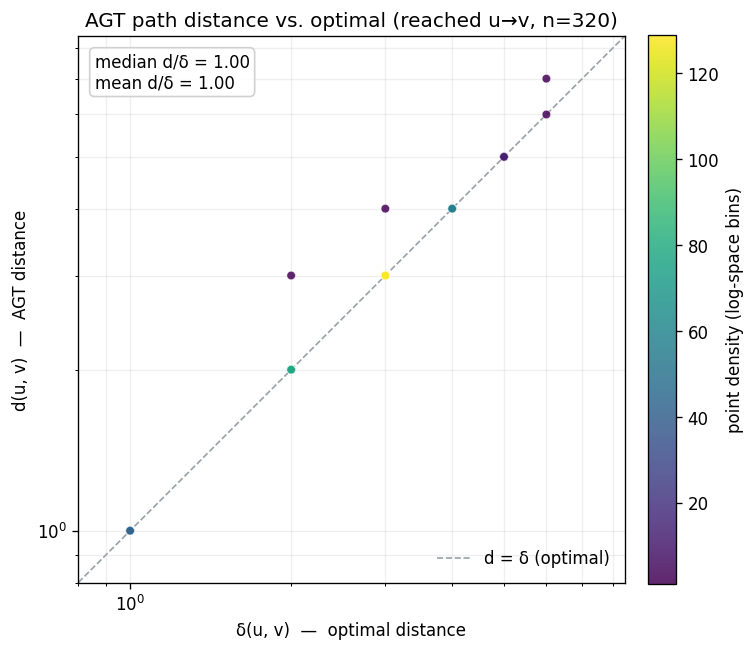

In [46]:
# Plot the AGT distance against the optimal distance.
reached = metrics['reached']
delta = np.array([x for x, r in zip(metrics['opt_dist'], reached) if r])
distance = np.array([y for y, r in zip(metrics['agt_dist'], reached) if r])
ratio = distance / delta
if len(distance) == 0:
    print('No (u, v) pair was reached; nothing to plot.')
else:

    # Ensure that the data span orders of magnitude.
    lx, ly = np.log10(delta), np.log10(distance)
    H, xe, ye = np.histogram2d(lx, ly, bins=40)
    ix = np.clip(np.searchsorted(xe, lx) - 1, 0, H.shape[0] - 1)
    iy = np.clip(np.searchsorted(ye, ly) - 1, 0, H.shape[1] - 1)
    dens = H[ix, iy]; order = dens.argsort()
    lo = min(delta.min(), distance.min()) * 0.8
    hi = max(delta.max(), distance.max()) * 1.2
    fig, ax = plt.subplots(figsize=(6.4, 6), dpi=120)
    ax.plot([lo, hi], [lo, hi], ls='--', lw=1, color='#9aa0a6', zorder=1, label='d = \u03b4 (optimal)')
    sc = ax.scatter(delta[order], distance[order], c=dens[order], s=26, cmap='viridis',
                    alpha=0.85, edgecolors='white', linewidths=0.3, zorder=2)
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04); cb.set_label('point density (log-space bins)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.set_xlabel('\u03b4(u, v)  \u2014  optimal distance'); ax.set_ylabel('d(u, v)  \u2014  AGT distance')
    ax.set_title(f'AGT path distance vs. optimal (reached u\u2192v, n={len(distance)})')
    ax.text(0.03, 0.97, f"median d/\u03b4 = {np.median(ratio):.2f}\nmean d/\u03b4 = {ratio.mean():.2f}",
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', fc='white', ec='#cccccc', alpha=0.9))
    ax.legend(frameon=False, loc='lower right'); ax.grid(alpha=0.2, which='both')
    plt.tight_layout(); display(fig); plt.close(fig)

In [47]:
# Check graph diameters.
for graph in test_dataloader.dataset:
    print(graph.num_nodes, graph.diameter)

104 7
103 6
105 6
100 7
106 8
101 7
107 7
106 7
103 6
100 7
